# 미니프로젝트: 결측치·이상치·클래스 불균형 처리 (Vibe Coding)

#### <목표>
오늘 배운 **결측치/이상치 처리, Under/Oversampling, SVDD**를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- Telco Customer Churn (통신사 고객 이탈 데이터)
- 고객의 인적사항, 가입 서비스, 요금·계약 정보와 이탈(Churn) 여부를 담은 데이터

| 변수명 | 설명 |
|:---:|:---|
| gender, SeniorCitizen, Partner, Dependents | 고객 인적사항 |
| tenure | 가입 개월 수 |
| PhoneService, MultipleLines, InternetService 등 | 가입 서비스 종류 |
| Contract, PaperlessBilling, PaymentMethod | 계약/결제 정보 |
| MonthlyCharges, TotalCharges | 월/누적 요금 |
| Churn | 이탈 여부 (Yes: 이탈, No: 유지) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `Churn` | 고객 정보로 이탈 여부 예측 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day4_miniproject.csv` 파일을 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)

**[과제]** 써니는 통신사 고객 이탈 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리를 호출하고 데이터를 불러와 구조를 확인하는 코드를 AI와 상의해서 작성하세요.

In [18]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
)
from sklearn.model_selection import train_test_split, StratifiedKFold

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import OneClassSVM

from imblearn.combine import SMOTETomek
from imblearn.over_sampling import ADASYN, SMOTE
from imblearn.under_sampling import TomekLinks

from xgboost import XGBClassifier


def setup_korean_font():
    """matplotlib/seaborn 한글 폰트 적용. sns.set_theme() 호출 후 재호출 필요."""
    try:
        _korean_fonts = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Gulim"]
        _available = {f.name for f in fm.fontManager.ttflist}
        for _font in _korean_fonts:
            if _font in _available:
                plt.rcParams["font.family"] = _font
                break
        else:
            print("[경고] 한글 폰트를 찾지 못했습니다. 기본 폰트를 사용합니다.")
        plt.rcParams["axes.unicode_minus"] = False
    except Exception as e:
        print(f"[경고] 한글 폰트 설정 중 오류 발생: {e}. 기본 폰트를 사용합니다.")
        plt.rcParams["axes.unicode_minus"] = False


def evaluate_classifier(y_true, y_pred, y_score=None):
    """분류 모델 성능 지표 반환 (y_score: ROC-AUC용 연속 점수)"""
    return {
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 3),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 3),
        "F1-score": round(f1_score(y_true, y_pred, zero_division=0), 3),
        "ROC-AUC": round(roc_auc_score(y_true, y_score), 3) if y_score is not None else np.nan,
    }


sns.set_theme(style="whitegrid", palette="husl", font_scale=1.05)
setup_korean_font()

# 데이터 불러오기
df_raw = pd.read_csv("dataset/day4_miniproject.csv")
print(f"데이터 크기: {df_raw.shape[0]:,}행 × {df_raw.shape[1]}열")
print(f"컬럼 목록: {list(df_raw.columns)}")
df_raw.head()

데이터 크기: 7,043행 × 20열
컬럼 목록: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


d:\autornd\SK Autonomous R&D\AutoRnDEnv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1) 데이터 탐색 (EDA)

### 1-1) 기본 EDA 진행

**[과제]** 써니는 데이터 분석 전, 데이터의 구조적 및 통계적 정보가 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [2]:
print("=" * 60)
print("1) 데이터 구조")
print("=" * 60)
print(f"행 수: {len(df_raw):,}  |  열 수: {df_raw.shape[1]}")
print(f"\n[데이터 타입]\n{df_raw.dtypes}")

print("\n" + "=" * 60)
print("2) 기술 통계 — 수치형 변수")
print("=" * 60)
display(df_raw.describe(include="number").T.round(2))

print("\n" + "=" * 60)
print("3) 범주형 변수 요약")
print("=" * 60)
cat_cols_raw = df_raw.select_dtypes(include=["object"]).columns
cat_summary = pd.DataFrame({
    "고유값 수": [df_raw[c].nunique() for c in cat_cols_raw],
    "최빈값": [df_raw[c].mode().iloc[0] for c in cat_cols_raw],
    "최빈값 비율(%)": [(df_raw[c].value_counts(normalize=True).iloc[0] * 100).round(1) for c in cat_cols_raw],
}, index=cat_cols_raw)
display(cat_summary)

print("\n" + "=" * 60)
print("4) 타겟(Churn) 분포")
print("=" * 60)
print(df_raw["Churn"].value_counts())
print(f"\n결측치 총합: {df_raw.isnull().sum().sum():,}개")

1) 데이터 구조
행 수: 7,043  |  열 수: 20

[데이터 타입]
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure              float64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

2) 기술 통계 — 수치형 변수


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.16,0.37,0.00,0.00,0.00,0.00,1.00
tenure,6832.0,32.38,24.57,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,6832.0,64.76,30.08,18.25,35.59,70.35,89.85,118.75
TotalCharges,7032.0,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80



3) 범주형 변수 요약


,고유값 수,최빈값,최빈값 비율(%)
gender,2,Male,50.5
Partner,2,No,51.7
Dependents,2,No,70.0
PhoneService,2,Yes,90.3
MultipleLines,3,No,48.1
InternetService,3,Fiber optic,43.9
OnlineSecurity,3,No,49.7
OnlineBackup,3,No,43.8
DeviceProtection,3,No,43.9
TechSupport,3,No,49.3



4) 타겟(Churn) 분포
Churn
No     5174
Yes    1869
Name: count, dtype: int64

결측치 총합: 784개


**[과제]** 써니는 EDA를 통해 전처리가 필요한 부분을 발견했습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

> Tip: 'Churn' 변수의 타입이나 값 표기 방식

[Churn 변환]
  변환 전: ['No' 'Yes']
  변환 후: [np.int64(0), np.int64(1)]  (0=유지, 1=이탈)

[TotalCharges] tenure=0 & 결측 → MonthlyCharges 대치: 11건

[전처리 체크리스트]


,항목,상태
0,결측치,처리 필요
1,Churn 인코딩,완료
2,범주형 인코딩,섹션 4 예정
3,클래스 불균형,확인 필요
4,이상치,확인 필요


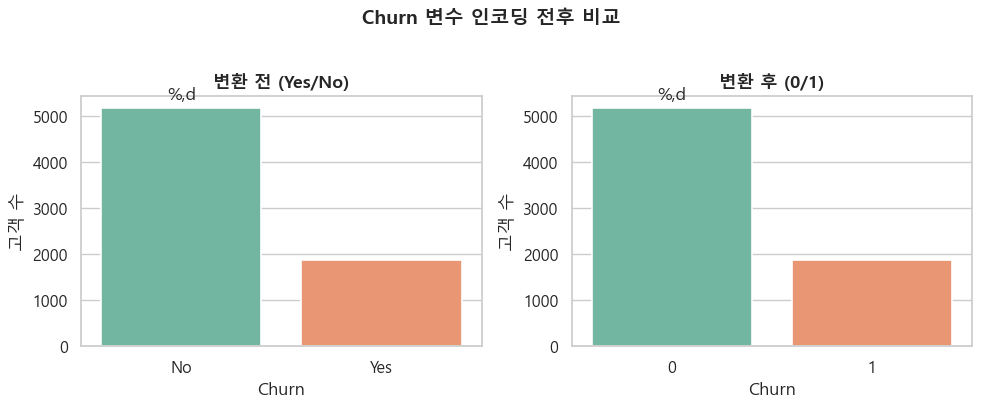

In [3]:
df = df_raw.copy()

# 1) TotalCharges: 문자열 → 숫자 변환
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# 2) Churn: Yes/No → 0/1 이진 인코딩
churn_map = {"No": 0, "Yes": 1}
print("[Churn 변환]")
print(f"  변환 전: {df_raw['Churn'].unique()}")
df["Churn"] = df["Churn"].map(churn_map)
print(f"  변환 후: {sorted(df['Churn'].dropna().unique())}  (0=유지, 1=이탈)")

# 3) tenure=0 신규 고객의 TotalCharges 결측 → MonthlyCharges로 값 기반 대치
mask_new = (df["tenure"] == 0) & df["TotalCharges"].isna()
n_filled = mask_new.sum()
df.loc[mask_new, "TotalCharges"] = df.loc[mask_new, "MonthlyCharges"]
print(f"\n[TotalCharges] tenure=0 & 결측 → MonthlyCharges 대치: {n_filled}건")

# 4) 전처리 필요 포인트 시각화
issue_df = pd.DataFrame({
    "항목": ["결측치", "Churn 인코딩", "범주형 인코딩", "클래스 불균형", "이상치"],
    "상태": ["처리 필요", "완료", "섹션 4 예정", "확인 필요", "확인 필요"],
})
print("\n[전처리 체크리스트]")
display(issue_df)

# Churn 변환 전후 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (title, series) in zip(
    axes,
    [("변환 전 (Yes/No)", df_raw["Churn"]), ("변환 후 (0/1)", df["Churn"])],
):
    counts = series.value_counts()
    sns.barplot(x=counts.index.astype(str), y=counts.values, hue=counts.index.astype(str),
                palette="Set2", edgecolor="white", linewidth=1.2, dodge=False, legend=False, ax=ax)
    ax.bar_label(ax.containers[0], fmt="%,d", padding=3)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Churn")
    ax.set_ylabel("고객 수")
fig.suptitle("Churn 변수 인코딩 전후 비교", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 1-2) 결측치 현황 파악

**[과제]** 써니는 데이터에 결측치가 존재하는지, 존재한다면 어떤 형태로 얼마나 있는지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

결측치 현황


,결측 수,결측 비율(%)
tenure,211,3.00
PaymentMethod,211,3.00
MonthlyCharges,211,3.00
InternetService,140,1.99


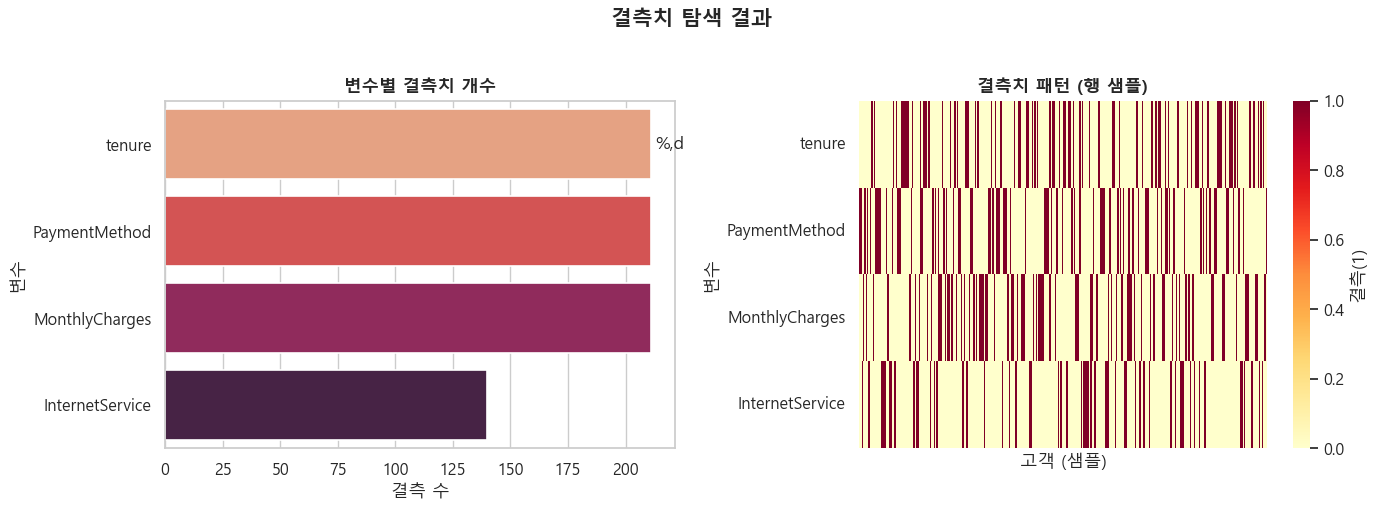


결측 포함 행: 752개 (10.7%)
결측 행의 Churn 분포:
Churn
0    549
1    203
Name: count, dtype: int64


In [4]:
# 결측치 현황 집계
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"결측 수": missing, "결측 비율(%)": missing_pct})

print("=" * 50)
print("결측치 현황")
print("=" * 50)
display(missing_df)

# 결측치 시각화
setup_korean_font()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) 컬럼별 결측 수 막대그래프
sns.barplot(
    data=missing_df.reset_index(names="변수"),
    x="결측 수", y="변수",
    hue="변수", palette="rocket_r",
    edgecolor="white", linewidth=1.2, dodge=False, legend=False, ax=axes[0],
)
axes[0].bar_label(axes[0].containers[0], fmt="%,d", padding=3)
axes[0].set_title("변수별 결측치 개수", fontweight="bold")
axes[0].set_xlabel("결측 수")

# (2) 결측 패턴 히트맵 (결측 있는 행만 샘플링)
missing_rows = df[missing.index].isnull()
if len(missing_rows) > 300:
    sample_idx = missing_rows[missing_rows.any(axis=1)].sample(300, random_state=42).index
    heat_data = df.loc[sample_idx, missing.index].isnull().astype(int)
else:
    heat_data = missing_rows.astype(int)

sns.heatmap(
    heat_data.T, cmap="YlOrRd", cbar_kws={"label": "결측(1)"},
    yticklabels=missing.index, xticklabels=False, ax=axes[1],
)
axes[1].set_title("결측치 패턴 (행 샘플)", fontweight="bold")
axes[1].set_xlabel("고객 (샘플)")
axes[1].set_ylabel("변수")

fig.suptitle("결측치 탐색 결과", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# 결측 행의 Churn 분포 확인
rows_with_missing = df[df.isnull().any(axis=1)]
print(f"\n결측 포함 행: {len(rows_with_missing):,}개 ({len(rows_with_missing)/len(df)*100:.1f}%)")
print("결측 행의 Churn 분포:")
print(rows_with_missing["Churn"].value_counts())

### 1-3) 클래스 불균형 확인

**[과제]** 써니는 Churn 비율이 얼마나 불균형한지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

Churn 클래스 분포


,클래스,고객 수,비율(%)
0,0 (유지),5174,73.46
1,1 (이탈),1869,26.54



불균형 비율 (유지:이탈) = 2.77 : 1
→ 이탈(소수) 클래스가 약 26%, Resampling 또는 One-Class Learning 검토 필요


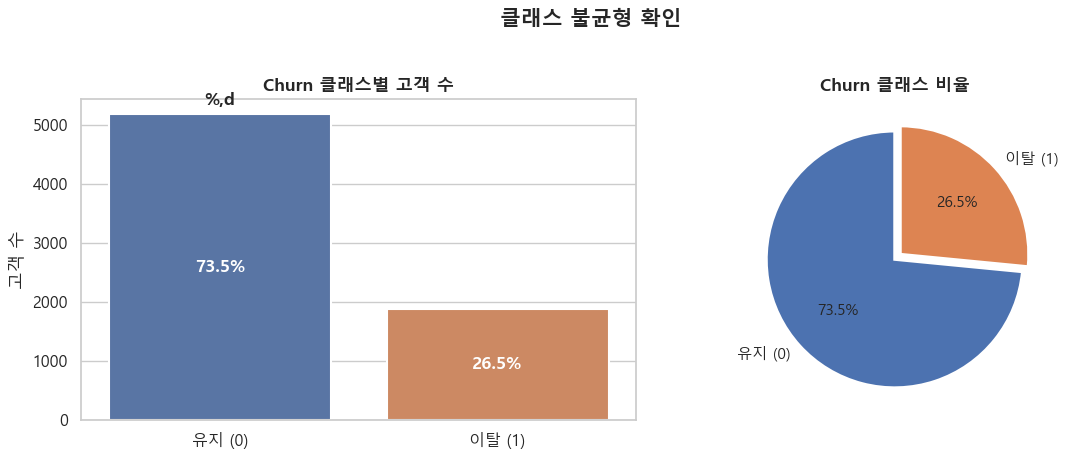

In [5]:
churn_counts = df["Churn"].value_counts().sort_index()
churn_ratio = df["Churn"].value_counts(normalize=True).sort_index()

print("=" * 50)
print("Churn 클래스 분포")
print("=" * 50)
summary = pd.DataFrame({
    "클래스": ["0 (유지)", "1 (이탈)"],
    "고객 수": churn_counts.values,
    "비율(%)": (churn_ratio.values * 100).round(2),
})
display(summary)
imbalance_ratio = churn_counts[0] / churn_counts[1]
print(f"\n불균형 비율 (유지:이탈) = {imbalance_ratio:.2f} : 1")
print("→ 이탈(소수) 클래스가 약 26%, Resampling 또는 One-Class Learning 검토 필요")

# 시각화
setup_korean_font()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
labels = ["유지 (0)", "이탈 (1)"]
colors = ["#4C72B0", "#DD8452"]

# 막대그래프
sns.barplot(x=labels, y=churn_counts.values, hue=labels, palette=colors,
            edgecolor="white", linewidth=1.5, dodge=False, legend=False, ax=axes[0])
axes[0].bar_label(axes[0].containers[0], fmt="%,d", padding=4, fontweight="bold")
for i, pct in enumerate(churn_ratio.values * 100):
    axes[0].text(i, churn_counts.values[i] * 0.5, f"{pct:.1f}%",
                 ha="center", va="center", color="white", fontweight="bold")
axes[0].set_title("Churn 클래스별 고객 수", fontweight="bold")
axes[0].set_ylabel("고객 수")

# 파이차트
axes[1].pie(
    churn_counts.values, labels=labels, autopct="%1.1f%%",
    colors=colors, startangle=90, explode=(0, 0.06),
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11},
)
axes[1].set_title("Churn 클래스 비율", fontweight="bold")

fig.suptitle("클래스 불균형 확인", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 1-4) 이상치 후보 탐색

**[과제]** 써니는 수치형 변수에 이상치가 있는지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

IQR(1.5×) 기준 이상치 후보 통계


,Q1,Q3,IQR,하한,상한,이상치 수,이상치 비율(%)
SeniorCitizen,0.00,0.00,0.00,0.00,0.00,1142.0,16.21
tenure,9.00,55.00,46.00,-60.00,124.00,0.0,0.00
MonthlyCharges,35.59,89.85,54.26,-45.81,171.24,0.0,0.00
TotalCharges,398.55,3786.60,3388.05,-4683.52,8868.67,0.0,0.00


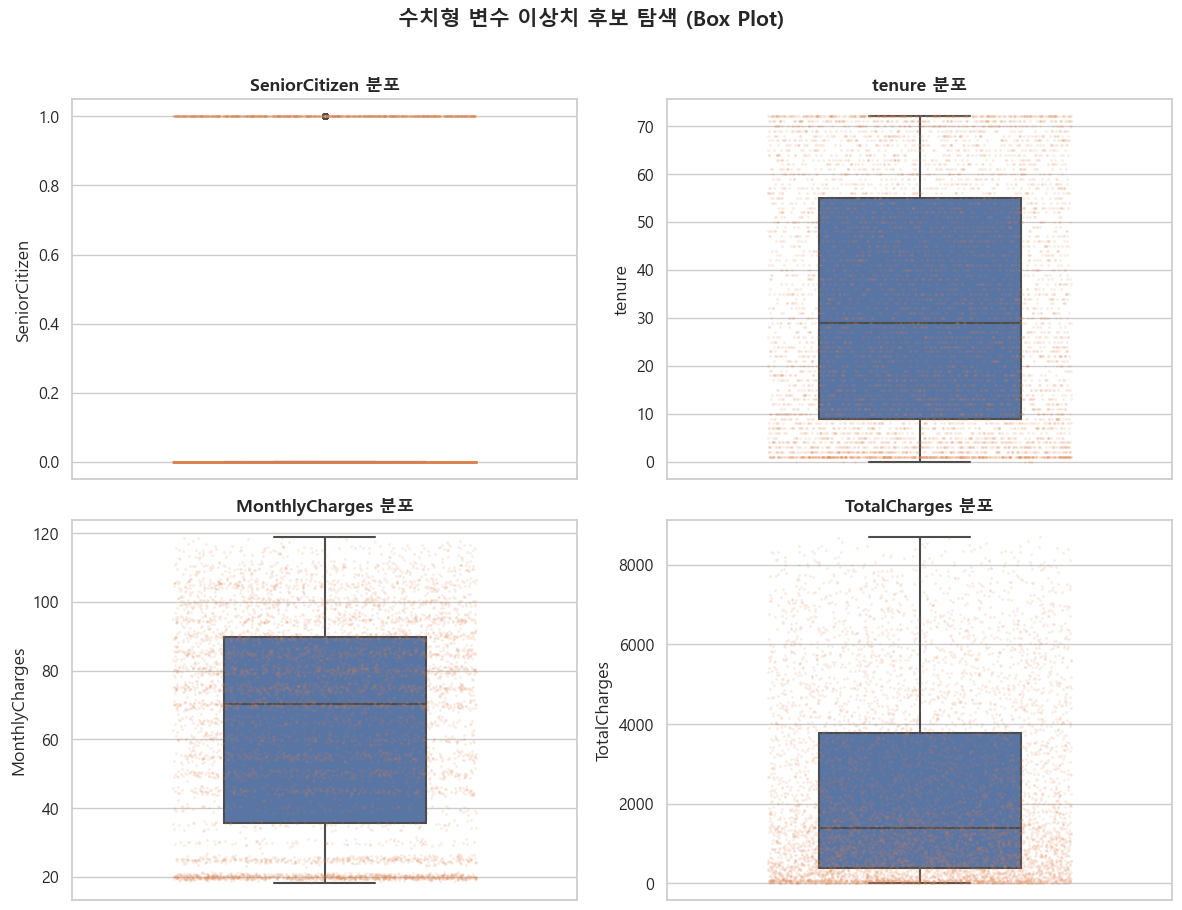

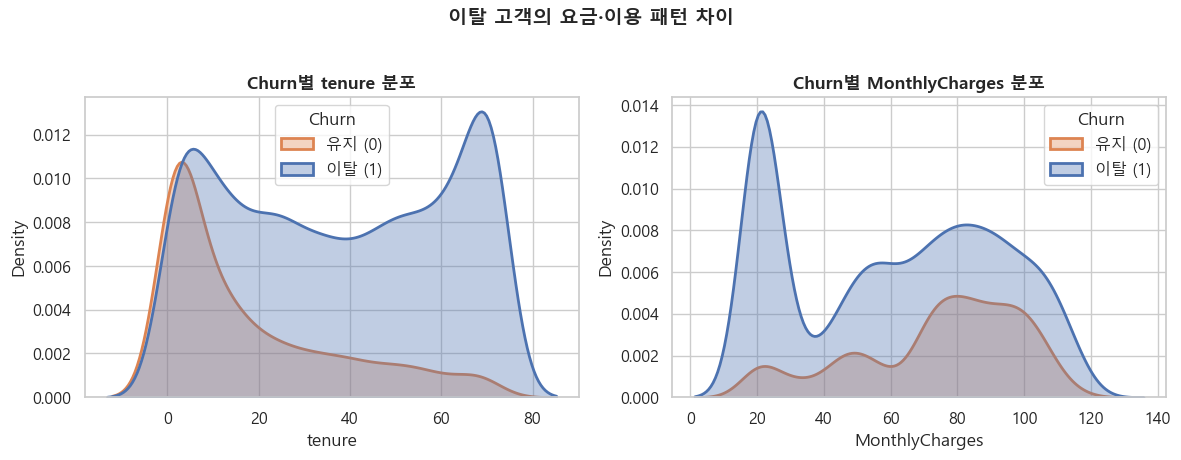


[인사이트] tenure·MonthlyCharges에서 이탈(1) 고객이 정상 범위 밖에 분포할 수 있음
→ 이상치 '행 제거' 시 소수 클래스(이탈) 손실 위험 → Winsorization(클리핑) 검토


In [6]:
NUM_COLS = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

# IQR 기반 이상치 후보 탐색
def iqr_outlier_stats(series, multiplier=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - multiplier * iqr, q3 + multiplier * iqr
    mask = (series < lower) | (series > upper)
    return {"Q1": q1, "Q3": q3, "IQR": iqr, "하한": lower, "상한": upper,
            "이상치 수": mask.sum(), "이상치 비율(%)": round(mask.mean() * 100, 2)}

outlier_stats = pd.DataFrame({c: iqr_outlier_stats(df[c]) for c in NUM_COLS}).T
print("=" * 60)
print("IQR(1.5×) 기준 이상치 후보 통계")
print("=" * 60)
display(outlier_stats.round(2))

# Box Plot 시각화
setup_korean_font()
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()
for ax, col in zip(axes, NUM_COLS):
    sns.boxplot(y=df[col], color="#4C72B0", width=0.4, linewidth=1.5,
                flierprops={"marker": "o", "markersize": 4, "alpha": 0.5}, ax=ax)
    sns.stripplot(y=df[col], color="#DD8452", alpha=0.15, size=2, jitter=0.3, ax=ax)
    ax.set_title(f"{col} 분포", fontweight="bold")
    ax.set_ylabel(col)

fig.suptitle("수치형 변수 이상치 후보 탐색 (Box Plot)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Churn별 tenure/MonthlyCharges 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col in zip(axes, ["tenure", "MonthlyCharges"]):
    sns.kdeplot(data=df, x=col, hue="Churn", hue_order=[0, 1],
                palette=["#4C72B0", "#DD8452"], fill=True, alpha=0.35, linewidth=2, ax=ax)
    ax.set_title(f"Churn별 {col} 분포", fontweight="bold")
    ax.set_xlabel(col)
    ax.legend(["유지 (0)", "이탈 (1)"], title="Churn")

fig.suptitle("이탈 고객의 요금·이용 패턴 차이", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print("\n[인사이트] tenure·MonthlyCharges에서 이탈(1) 고객이 정상 범위 밖에 분포할 수 있음")
print("→ 이상치 '행 제거' 시 소수 클래스(이탈) 손실 위험 → Winsorization(클리핑) 검토")

## 2) 결측치 처리

**[과제]** 써니는 데이터셋에 존재하는 결측치를 제거하거나 대치하려 합니다.

이때 변수마다 분포나 특성이 다르면 적합한 대치법도 달라질 수 있다고 생각합니다.

AI와 상의하여 변수별로 제거와 대치 중 어떤 방법이 적합한지 결정하고, 대치를 선택했다면 값 기반, 통계 기반(평균/중앙값/최빈값), 머신러닝 기반(KNN Imputer) 중 어떤 방식이 적합한지 정하여 적용해보세요.

결측치 처리 전략 및 적용
처리 전 결측치: 773개
  [InternetService] 최빈값 'Fiber optic' 대치 → 140건
  [PaymentMethod] 최빈값 'Electronic check' 대치 → 211건
  [수치형] KNN Imputer(k=5) 적용 → 422건 대치

처리 후 결측치: 0개
데이터 크기: 7,043행 (행 삭제 없음)


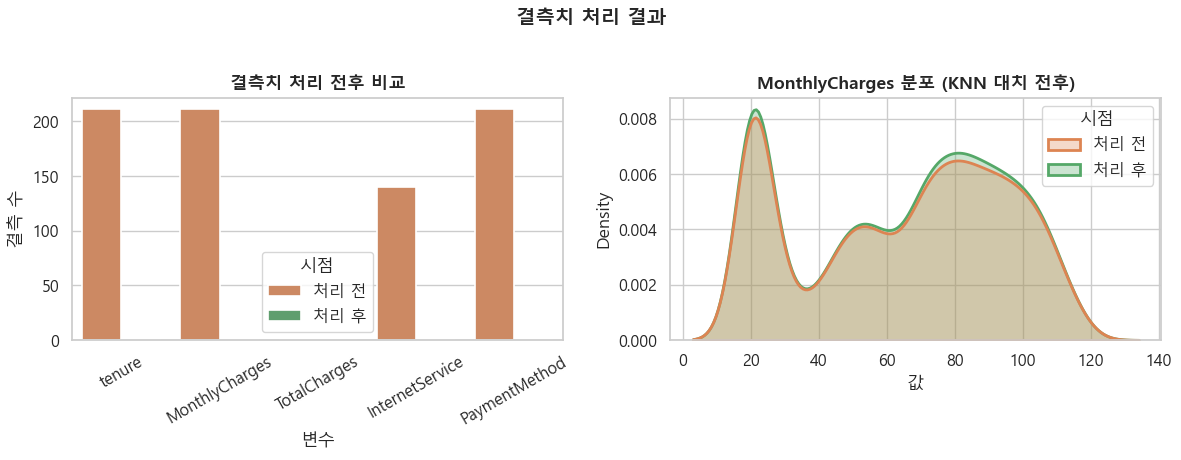

In [7]:
# ===== 결측치 처리 전략 =====
# 범주형(InternetService, PaymentMethod) → 최빈값(mode) 대치: 범주 특성상 통계 대표값 적합
# 수치형(tenure, MonthlyCharges, TotalCharges) → KNN Imputer: 변수 간 상관관계 활용
# SeniorCitizen → 결측 없음

df_imputed = df.copy()
cat_missing_cols = ["InternetService", "PaymentMethod"]
num_missing_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

print("=" * 60)
print("결측치 처리 전략 및 적용")
print("=" * 60)
print(f"처리 전 결측치: {df_imputed.isnull().sum().sum():,}개")

# 1) 범주형 — 최빈값 대치
for col in cat_missing_cols:
    mode_val = df_imputed[col].mode()[0]
    n_miss = df_imputed[col].isnull().sum()
    df_imputed[col] = df_imputed[col].fillna(mode_val)
    print(f"  [{col}] 최빈값 '{mode_val}' 대치 → {n_miss}건")

# 2) 수치형 — KNN Imputer (k=5)
knn_imputer = KNNImputer(n_neighbors=5)
before = df_imputed[num_missing_cols].copy()
df_imputed[num_missing_cols] = knn_imputer.fit_transform(df_imputed[num_missing_cols])
print(f"  [수치형] KNN Imputer(k=5) 적용 → {before.isnull().sum().sum()}건 대치")

print(f"\n처리 후 결측치: {df_imputed.isnull().sum().sum():,}개")
print(f"데이터 크기: {df_imputed.shape[0]:,}행 (행 삭제 없음)")

# 처리 전후 비교 시각화
setup_korean_font()
compare_cols = num_missing_cols + cat_missing_cols
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

missing_before = df[compare_cols].isnull().sum()
missing_after = df_imputed[compare_cols].isnull().sum()
miss_compare = pd.DataFrame({"처리 전": missing_before, "처리 후": missing_after}).reset_index(names="변수")

miss_melt = miss_compare.melt(id_vars="변수", var_name="시점", value_name="결측 수")
sns.barplot(data=miss_melt, x="변수", y="결측 수", hue="시점",
            palette={"처리 전": "#DD8452", "처리 후": "#55A868"},
            edgecolor="white", linewidth=1.2, ax=axes[0])
axes[0].set_title("결측치 처리 전후 비교", fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)

# KNN 대치 전후 MonthlyCharges 분포
plot_df = pd.concat([
    before["MonthlyCharges"].reset_index(drop=True).to_frame(name="값").assign(시점="처리 전"),
    df_imputed["MonthlyCharges"].reset_index(drop=True).to_frame(name="값").assign(시점="처리 후"),
], ignore_index=True)
sns.kdeplot(data=plot_df, x="값", hue="시점", palette=["#DD8452", "#55A868"],
            fill=True, alpha=0.3, linewidth=2, ax=axes[1])
axes[1].set_title("MonthlyCharges 분포 (KNN 대치 전후)", fontweight="bold")

fig.suptitle("결측치 처리 결과", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 3) 이상치 처리

**[과제]** 써니는 데이터셋에 존재하는 이상치를 제거하고자 합니다.

다만 이탈(Churn) 고객이 실제로는 "정상 범위를 벗어난" 요금 및 이용 패턴을 가진 고객일 수 있다는 점이 마음에 걸립니다. 이상치 제거가 소수 클래스(Churn)를 함께 지워버릴 위험은 없는지 AI와 상의하여 검토하고 안전한 처리 기준을 정해 적용해 보세요.

이상치 처리 — Churn 소수 클래스 보호 검토
IQR 이상치 포함 행: 0개 (0.0%)

[이상치 행의 Churn 분포]
Series([], Name: count, dtype: int64)
→ 이상치 행 중 이탈(1) 비율: nan%
→ 전체 이탈 비율: 26.5%

[순차 IQR 행 제거 시] 0행 삭제, 이탈(1) 0명 손실 (0.0%)
→ 행 제거는 소수 클래스 손실 위험 → Winsorization(클리핑) 선택

[Winsorization 적용] 클리핑된 값: 0개, 행 수 유지: 7,043


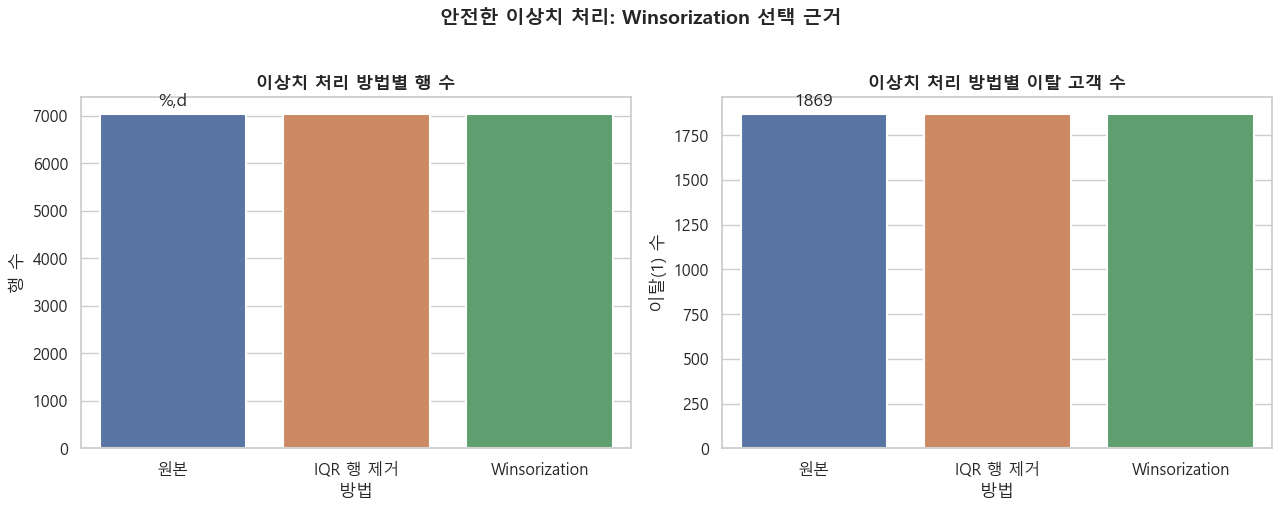

In [8]:
def count_iqr_outlier_rows(data, cols, multiplier=1.5):
    """모든 수치형 컬럼에 IQR 필터를 순차 적용했을 때 제거되는 행 수"""
    temp = data.copy()
    for col in cols:
        q1, q3 = temp[col].quantile(0.25), temp[col].quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            continue
        lower, upper = q1 - multiplier * iqr, q3 + multiplier * iqr
        temp = temp[temp[col].between(lower, upper)]
    return len(data) - len(temp)


def winsorize_iqr(data, cols, multiplier=1.5):
    """행 삭제 없이 IQR 경계값으로 클리핑"""
    clipped = data.copy()
    n_clipped = 0
    for col in cols:
        q1, q3 = clipped[col].quantile(0.25), clipped[col].quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            continue
        lower, upper = q1 - multiplier * iqr, q3 + multiplier * iqr
        before = clipped[col].copy()
        clipped[col] = clipped[col].clip(lower=lower, upper=upper)
        n_clipped += (before != clipped[col]).sum()
    return clipped, n_clipped


# Churn 소수 클래스 보호 검토
outlier_mask = pd.Series(False, index=df_imputed.index)
for col in NUM_COLS:
    q1, q3 = df_imputed[col].quantile(0.25), df_imputed[col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_mask |= (df_imputed[col] < lower) | (df_imputed[col] > upper)

print("=" * 60)
print("이상치 처리 — Churn 소수 클래스 보호 검토")
print("=" * 60)
print(f"IQR 이상치 포함 행: {outlier_mask.sum():,}개 ({outlier_mask.mean()*100:.1f}%)")
print("\n[이상치 행의 Churn 분포]")
print(df_imputed.loc[outlier_mask, "Churn"].value_counts())
print(f"→ 이상치 행 중 이탈(1) 비율: {df_imputed.loc[outlier_mask, 'Churn'].mean()*100:.1f}%")
print(f"→ 전체 이탈 비율: {df_imputed['Churn'].mean()*100:.1f}%")

# 순차 IQR 행 제거 시뮬레이션
temp = df_imputed.copy()
for col in NUM_COLS:
    q1, q3 = temp[col].quantile(0.25), temp[col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    temp = temp[temp[col].between(lower, upper)]
churn_lost = df_imputed["Churn"].sum() - temp["Churn"].sum()
n_removed = len(df_imputed) - len(temp)
print(f"\n[순차 IQR 행 제거 시] {n_removed:,}행 삭제, 이탈(1) {churn_lost:.0f}명 손실 ({churn_lost/df_imputed['Churn'].sum()*100:.1f}%)")
print("→ 행 제거는 소수 클래스 손실 위험 → Winsorization(클리핑) 선택")

df_clean, n_clipped = winsorize_iqr(df_imputed, NUM_COLS)
print(f"\n[Winsorization 적용] 클리핑된 값: {n_clipped:,}개, 행 수 유지: {len(df_clean):,}")

# 시각화
setup_korean_font()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

method_df = pd.DataFrame({
    "방법": ["원본", "IQR 행 제거", "Winsorization"],
    "행 수": [len(df_imputed), len(temp), len(df_clean)],
    "이탈(1) 수": [df_imputed["Churn"].sum(), temp["Churn"].sum(), df_clean["Churn"].sum()],
})
sns.barplot(data=method_df, x="방법", y="행 수", hue="방법",
            palette=["#4C72B0", "#DD8452", "#55A868"],
            edgecolor="white", linewidth=1.5, dodge=False, legend=False, ax=axes[0])
axes[0].bar_label(axes[0].containers[0], fmt="%,d", padding=3)
axes[0].set_title("이상치 처리 방법별 행 수", fontweight="bold")

sns.barplot(data=method_df, x="방법", y="이탈(1) 수", hue="방법",
            palette=["#4C72B0", "#DD8452", "#55A868"],
            edgecolor="white", linewidth=1.5, dodge=False, legend=False, ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fmt="%.0f", padding=3)
axes[1].set_title("이상치 처리 방법별 이탈 고객 수", fontweight="bold")

fig.suptitle("안전한 이상치 처리: Winsorization 선택 근거", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4) 데이터 분할 및 스케일링/인코딩

**[과제]** 써니는 모델 구축 전 학습/테스트 데이터를 나누려고 합니다. 클래스 불균형이 심한 상황에서 어떤 분할 방법이 적합할지 AI와 상의해서 정하고 나눠 보세요.

학습/테스트 분할 (stratified, 80:20)
학습: 5,634행  |  테스트: 1,409행


,학습,테스트,학습 비율(%),테스트 비율(%)
유지 (0),4139,1035,73.46,73.46
이탈 (1),1495,374,26.54,26.54


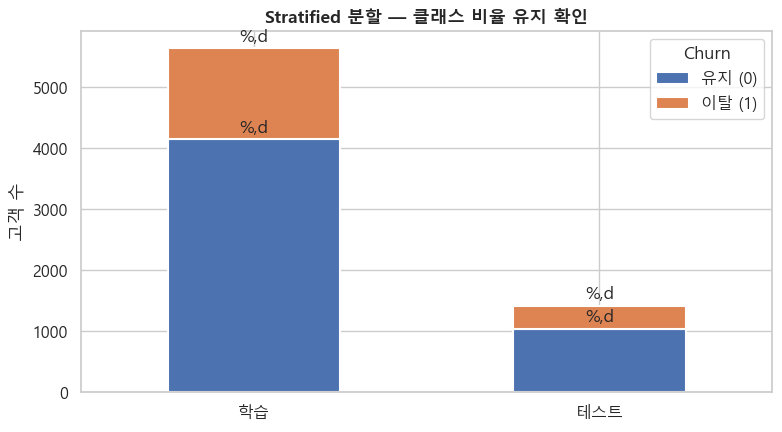

In [9]:
# 최종 전처리 데이터
data = df_clean.copy()
X = data.drop("Churn", axis=1)
y = data["Churn"]

# 클래스 불균형 → stratify 분할 (각 split에서 Churn 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

print("=" * 60)
print("학습/테스트 분할 (stratified, 80:20)")
print("=" * 60)
print(f"학습: {X_train.shape[0]:,}행  |  테스트: {X_test.shape[0]:,}행")

split_summary = pd.DataFrame({
    "학습": y_train.value_counts().sort_index(),
    "테스트": y_test.value_counts().sort_index(),
})
split_summary.index = ["유지 (0)", "이탈 (1)"]
split_summary["학습 비율(%)"] = (y_train.value_counts(normalize=True).sort_index() * 100).round(2).values
split_summary["테스트 비율(%)"] = (y_test.value_counts(normalize=True).sort_index() * 100).round(2).values
display(split_summary)

# 시각화
setup_korean_font()
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_data = pd.DataFrame({
    "유지 (0)": [y_train.value_counts()[0], y_test.value_counts()[0]],
    "이탈 (1)": [y_train.value_counts()[1], y_test.value_counts()[1]],
}, index=["학습", "테스트"])
plot_data.plot(kind="bar", stacked=True, color=["#4C72B0", "#DD8452"],
               edgecolor="white", linewidth=1.5, ax=ax)
ax.set_title("Stratified 분할 — 클래스 비율 유지 확인", fontweight="bold")
ax.set_ylabel("고객 수")
ax.set_xlabel("")
ax.legend(title="Churn", loc="upper right")
ax.bar_label(ax.containers[0], fmt="%,d", padding=2)
ax.bar_label(ax.containers[1], fmt="%,d", padding=2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**[과제]** 써니는 분할한 학습/테스트 데이터에 적절한 스케일링 및 인코딩을 적용하고자 합니다. AI와 상의하여 수치형 변수와 범주형 변수 각각에 적합한 스케일링 및 인코딩 방식을 정하고 적용해보세요.

수치형 변수: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
범주형 변수: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

인코딩·스케일링 후 feature 수: 30
학습 shape: (5634, 30)  |  테스트 shape: (1409, 30)


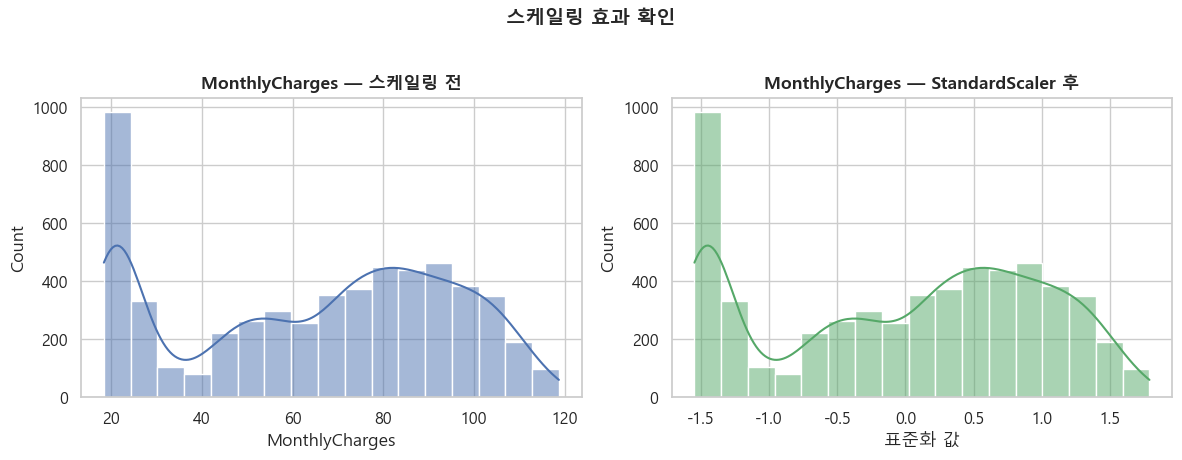

In [10]:
cat_features = X.select_dtypes(include=["object"]).columns.tolist()
num_features = X.select_dtypes(include="number").columns.tolist()

print("수치형 변수:", num_features)
print("범주형 변수:", cat_features)

# 수치형 → StandardScaler (KNN/SVM/XGBoost 등 거리·스케일 기반 모델 대비)
# 범주형 → OneHotEncoder (drop_first=True로 다중공선성 완화)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False), cat_features),
    ],
    remainder="drop",
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print(f"\n인코딩·스케일링 후 feature 수: {X_train_scaled.shape[1]}")
print(f"학습 shape: {X_train_scaled.shape}  |  테스트 shape: {X_test_scaled.shape}")

# 스케일링 전후 분포 비교 (MonthlyCharges 예시)
setup_korean_font()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
idx_mc = num_features.index("MonthlyCharges")
sns.histplot(X_train["MonthlyCharges"], kde=True, color="#4C72B0", ax=axes[0])
axes[0].set_title("MonthlyCharges — 스케일링 전", fontweight="bold")

# 스케일링된 MonthlyCharges (ColumnTransformer 순서상 첫 num feature)
mc_scaled = X_train_scaled[:, idx_mc]
sns.histplot(mc_scaled, kde=True, color="#55A868", ax=axes[1])
axes[1].set_title("MonthlyCharges — StandardScaler 후", fontweight="bold")
axes[1].set_xlabel("표준화 값")

fig.suptitle("스케일링 효과 확인", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 5) 클래스 불균형 시각화 및 Resampling 적용

**[과제]** 써니는 Churn 여부에 따라 고객들의 데이터가 얼마나 잘 구분되는지 궁금합니다. t-SNE로 학습 데이터를 2차원에 시각화하여 두 클래스가 얼마나 겹쳐 있는지 AI와 함께 코드를 작성하고 분석해보세요.

t-SNE 완료 — 학습 데이터 5,634건, 2차원 투영
클래스 분포: {'유지 (0)': 4139, '이탈 (1)': 1495}


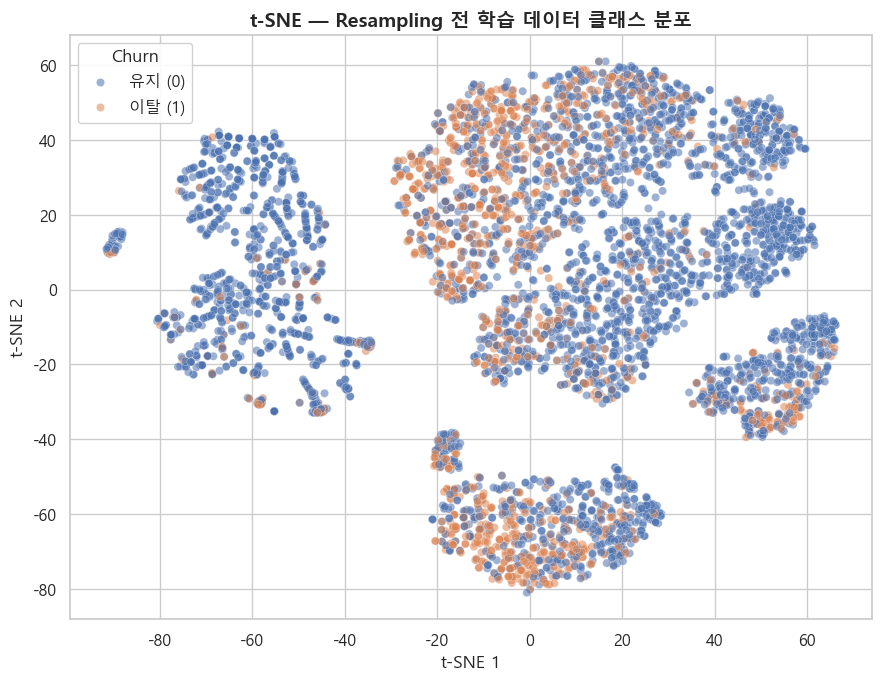


[분석] 두 클래스가 상당 부분 겹쳐 있으면 분류 난이도가 높음 → Resampling으로 경계 학습 보완 필요


In [11]:
# t-SNE: 고차원 학습 데이터를 2D로 투영하여 클래스 분리도 확인
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_train_scaled)

tsne_df = pd.DataFrame({"x": X_tsne[:, 0], "y": X_tsne[:, 1], "Churn": y_train.values})
tsne_df["Churn_label"] = tsne_df["Churn"].map({0: "유지 (0)", 1: "이탈 (1)"})

print(f"t-SNE 완료 — 학습 데이터 {len(tsne_df):,}건, 2차원 투영")
print("클래스 분포:", tsne_df["Churn_label"].value_counts().to_dict())

setup_korean_font()
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=tsne_df, x="x", y="y", hue="Churn_label",
    hue_order=["유지 (0)", "이탈 (1)"],
    palette={"유지 (0)": "#4C72B0", "이탈 (1)": "#DD8452"},
    alpha=0.55, s=35, edgecolor="white", linewidth=0.3, ax=ax,
)
ax.set_title("t-SNE — Resampling 전 학습 데이터 클래스 분포", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(title="Churn", loc="best", framealpha=0.9)
plt.tight_layout()
plt.show()

print("\n[분석] 두 클래스가 상당 부분 겹쳐 있으면 분류 난이도가 높음 → Resampling으로 경계 학습 보완 필요")

**[과제]** 써니는 클래스 불균형을 완화하기 위해 여러 Resampling 기법(TomekLinks, SMOTE, SMOTE+TomekLinks, ADASYN)을 학습 데이터에 적용해보고 t-SNE로 데이터 분포가 어떻게 변하는지 궁금해졌습니다. AI와 함께 관련 코드를 작성하고 분석해보세요.

> Tip: Resampling은 학습 데이터에만 적용하고, 테스트 데이터는 원본 그대로 유지할 것

Resampling 기법별 클래스 분포
  [원본] 유지(0)=4,139, 이탈(1)=1,495, 합계=5,634
  [TomekLinks] 유지(0)=3,763, 이탈(1)=1,495, 합계=5,258
  [SMOTE] 유지(0)=4,139, 이탈(1)=4,139, 합계=8,278
  [SMOTE+Tomek] 유지(0)=3,979, 이탈(1)=3,979, 합계=7,958
  [ADASYN] 유지(0)=4,139, 이탈(1)=4,081, 합계=8,220


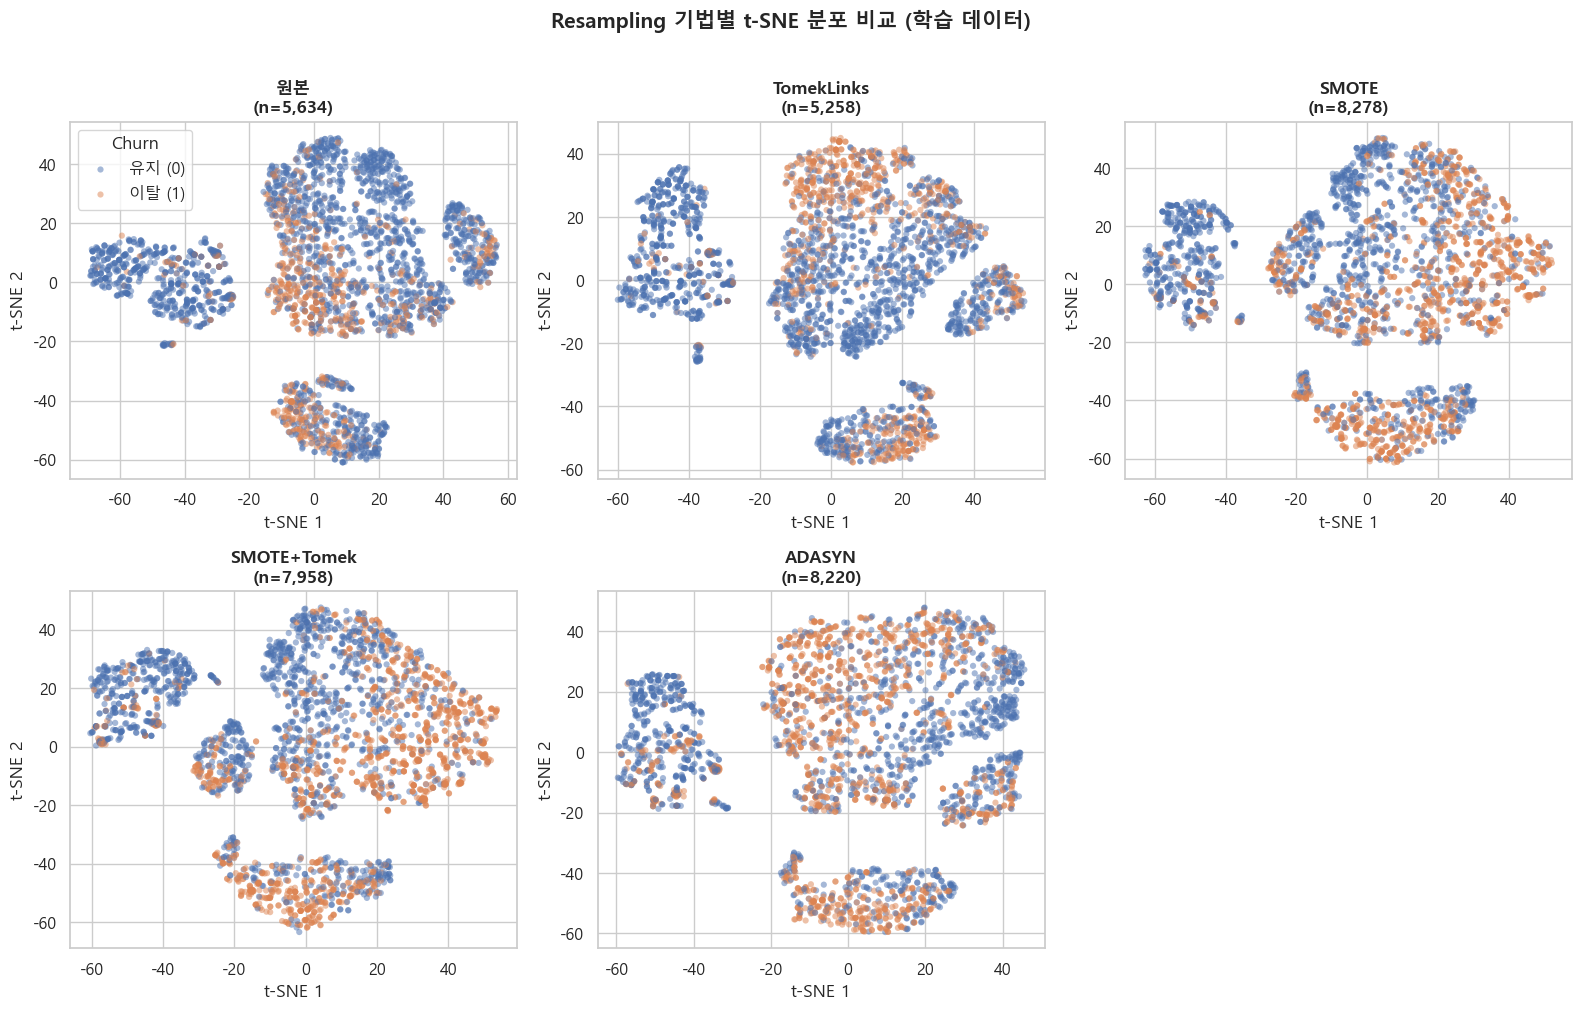

In [12]:
# Resampling 기법 적용 (학습 데이터만!)
sampling_methods = {
    "원본": (X_train_scaled, y_train),
    "TomekLinks": TomekLinks().fit_resample(X_train_scaled, y_train),
    "SMOTE": SMOTE(random_state=42).fit_resample(X_train_scaled, y_train),
    "SMOTE+Tomek": SMOTETomek(random_state=42).fit_resample(X_train_scaled, y_train),
    "ADASYN": ADASYN(random_state=42).fit_resample(X_train_scaled, y_train),
}

print("=" * 60)
print("Resampling 기법별 클래스 분포")
print("=" * 60)
for name, (_, y_s) in sampling_methods.items():
    vc = pd.Series(y_s).value_counts().sort_index()
    print(f"  [{name}] 유지(0)={vc[0]:,}, 이탈(1)={vc[1]:,}, 합계={len(y_s):,}")

# t-SNE 비교 시각화
setup_korean_font()
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for ax, (name, (X_s, y_s)) in zip(axes, sampling_methods.items()):
    X_arr = np.asarray(X_s)
    y_arr = np.asarray(y_s)
    if len(X_arr) > 3000:
        idx = np.random.RandomState(42).choice(len(X_arr), 3000, replace=False)
        X_sub, y_sub = X_arr[idx], y_arr[idx]
    else:
        X_sub, y_sub = X_arr, y_arr

    emb = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=800).fit_transform(X_sub)
    plot_df = pd.DataFrame({"x": emb[:, 0], "y": emb[:, 1],
                            "Churn": pd.Series(y_sub).map({0: "유지 (0)", 1: "이탈 (1)"})})
    sns.scatterplot(data=plot_df, x="x", y="y", hue="Churn",
                    hue_order=["유지 (0)", "이탈 (1)"],
                    palette={"유지 (0)": "#4C72B0", "이탈 (1)": "#DD8452"},
                    alpha=0.5, s=20, edgecolor="none", ax=ax, legend=(ax == axes[0]))
    ax.set_title(f"{name}\n(n={len(y_s):,})", fontweight="bold")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

axes[-1].axis("off")
fig.suptitle("Resampling 기법별 t-SNE 분포 비교 (학습 데이터)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**[과제]** 써니는 Resampling 기법별로 분류 모델(예: XGBoost)을 학습시켜 성능을 비교하려고 합니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

[원본] F1=0.589, Recall=0.532, Precision=0.659
[TomekLinks] F1=0.606, Recall=0.604, Precision=0.608
[SMOTE] F1=0.603, Recall=0.620, Precision=0.586
[SMOTE+Tomek] F1=0.601, Recall=0.634, Precision=0.571
[ADASYN] F1=0.607, Recall=0.620, Precision=0.595

Resampling × XGBoost 성능 비교


,Accuracy,Precision,Recall,F1-score,ROC-AUC
방법,,,,,
원본,0.803,0.659,0.532,0.589,0.839
TomekLinks,0.791,0.608,0.604,0.606,0.838
SMOTE,0.783,0.586,0.620,0.603,0.837
SMOTE+Tomek,0.776,0.571,0.634,0.601,0.836
ADASYN,0.787,0.595,0.620,0.607,0.833


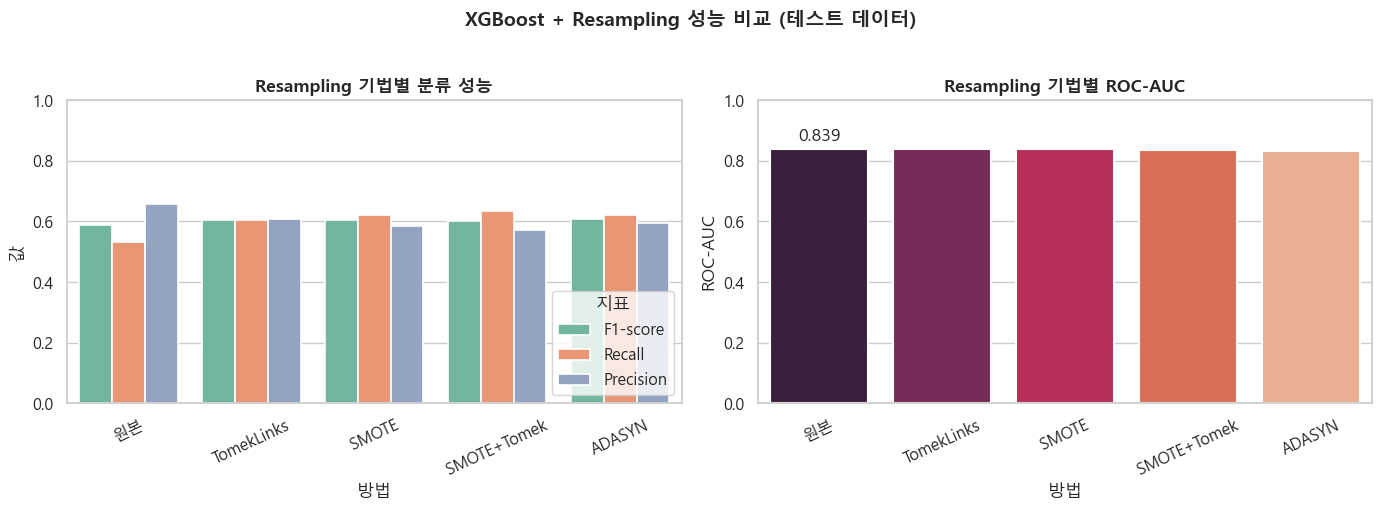


[최적 Resampling] F1-score 기준: ADASYN (0.607)


In [13]:
resampling_results = []
for name, (X_s, y_s) in sampling_methods.items():
    model = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        random_state=42, eval_metric="logloss", verbosity=0,
    )
    model.fit(X_s, y_s)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    metrics = evaluate_classifier(y_test, y_pred, y_proba)
    metrics["방법"] = name
    resampling_results.append(metrics)
    print(f"[{name}] F1={metrics['F1-score']:.3f}, Recall={metrics['Recall']:.3f}, Precision={metrics['Precision']:.3f}")

resampling_df = pd.DataFrame(resampling_results).set_index("방법")
print("\n" + "=" * 60)
print("Resampling × XGBoost 성능 비교")
print("=" * 60)
display(resampling_df)

# 시각화
setup_korean_font()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_melt = resampling_df.reset_index().melt(id_vars="방법", value_vars=["F1-score", "Recall", "Precision"],
                                                 var_name="지표", value_name="값")
sns.barplot(data=metrics_melt, x="방법", y="값", hue="지표",
            palette="Set2", edgecolor="white", linewidth=1.2, ax=axes[0])
axes[0].set_title("Resampling 기법별 분류 성능", fontweight="bold")
axes[0].tick_params(axis="x", rotation=25)
axes[0].set_ylim(0, 1)
axes[0].legend(title="지표", loc="lower right")

sns.barplot(data=resampling_df.reset_index(), x="방법", y="ROC-AUC",
            hue="방법", palette="rocket", edgecolor="white", linewidth=1.5,
            dodge=False, legend=False, ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fmt="%.3f", padding=3)
axes[1].set_title("Resampling 기법별 ROC-AUC", fontweight="bold")
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_ylim(0, 1)

fig.suptitle("XGBoost + Resampling 성능 비교 (테스트 데이터)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

best_method = resampling_df["F1-score"].idxmax()
print(f"\n[최적 Resampling] F1-score 기준: {best_method} ({resampling_df.loc[best_method, 'F1-score']:.3f})")

## 6) SVDD (One-Class SVM) 적용

**[과제]** 써니는 Resampling 방식 대신, 정상(Non-Churn) 데이터만으로 정상 영역을 학습하는 One-Class Learning 접근은 성능이 어떨지 궁금해졌습니다. AI와 함께 One-Class SVM(SVDD)을 정상 데이터로만 학습시키고 Churn 샘플이 그 경계 밖으로 얼마나 잘 걸러지는지 코드를 작성하고 분석해보세요.

> Tip: 정상 데이터로만 학습하고 테스트는 정상/이상 모두 진행

SVDD 학습 데이터 (정상만): 4,139행
테스트 데이터 (정상+이탈): 1,409행

One-Class SVM (nu=0.1) — Churn 탐지 성능
Accuracy    : 0.702
Precision   : 0.361
Recall      : 0.160
F1-score    : 0.222
ROC-AUC     : 0.574

혼동행렬 (행=실제, 열=예측):


,예측 유지(0),예측 이탈(1)
실제 유지(0),929,106
실제 이탈(1),314,60


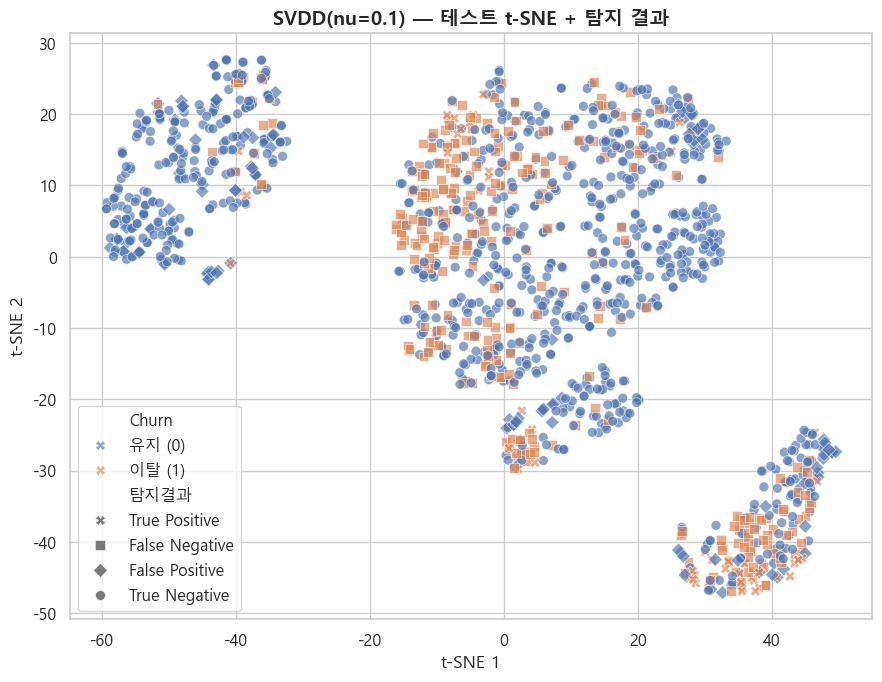


이탈(1) 374명 중 SVDD 경계 밖 탐지: 60명 (16.0%)
미탐지 (False Negative): 314명 (84.0%)


In [14]:
# SVDD (One-Class SVM): 정상(유지, Churn=0) 데이터만으로 학습
X_train_normal = X_train_scaled[y_train == 0]
print(f"SVDD 학습 데이터 (정상만): {X_train_normal.shape[0]:,}행")
print(f"테스트 데이터 (정상+이탈): {X_test_scaled.shape[0]:,}행")

oc_svm = OneClassSVM(kernel="rbf", gamma="auto", nu=0.1)
oc_svm.fit(X_train_normal)

# predict: +1=정상(inlier), -1=이상(outlier) → 이탈(1)로 변환
y_pred_oc = oc_svm.predict(X_test_scaled)
y_pred_churn = np.where(y_pred_oc == -1, 1, 0)
y_score_oc = -oc_svm.decision_function(X_test_scaled)

svdd_metrics = evaluate_classifier(y_test, y_pred_churn, y_score_oc)
print("\n" + "=" * 60)
print("One-Class SVM (nu=0.1) — Churn 탐지 성능")
print("=" * 60)
for k, v in svdd_metrics.items():
    print(f"{k:12s}: {v:.3f}" if v is not None else f"{k}: -")

cm = confusion_matrix(y_test, y_pred_churn)
cm_df = pd.DataFrame(cm, index=["실제 유지(0)", "실제 이탈(1)"],
                     columns=["예측 유지(0)", "예측 이탈(1)"])
print("\n혼동행렬 (행=실제, 열=예측):")
display(cm_df)

# 테스트 데이터 t-SNE + SVDD 탐지 결과 시각화
tsne_vis = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=800)
X_test_vis = tsne_vis.fit_transform(X_test_scaled)

test_plot = pd.DataFrame({
    "x": X_test_vis[:, 0], "y": X_test_vis[:, 1],
    "Churn": y_test.map({0: "유지 (0)", 1: "이탈 (1)"}).values,
})
test_plot["탐지결과"] = "True Negative"
test_plot.loc[(y_test.values == 1) & (y_pred_churn == 1), "탐지결과"] = "True Positive"
test_plot.loc[(y_test.values == 1) & (y_pred_churn == 0), "탐지결과"] = "False Negative"
test_plot.loc[(y_test.values == 0) & (y_pred_churn == 1), "탐지결과"] = "False Positive"

setup_korean_font()
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=test_plot, x="x", y="y", hue="Churn",
    hue_order=["유지 (0)", "이탈 (1)"],
    palette={"유지 (0)": "#4C72B0", "이탈 (1)": "#DD8452"},
    style="탐지결과",
    style_order=["True Positive", "False Negative", "False Positive", "True Negative"],
    markers={"True Positive": "X", "False Negative": "s", "False Positive": "D", "True Negative": "o"},
    alpha=0.65, s=50, ax=ax,
)
ax.set_title("SVDD(nu=0.1) — 테스트 t-SNE + 탐지 결과", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

n_tp = ((y_test == 1) & (y_pred_churn == 1)).sum()
n_fn = ((y_test == 1) & (y_pred_churn == 0)).sum()
n_churn = (y_test == 1).sum()
print(f"\n이탈(1) {n_churn}명 중 SVDD 경계 밖 탐지: {n_tp}명 ({n_tp/n_churn*100:.1f}%)")
print(f"미탐지 (False Negative): {n_fn}명 ({n_fn/n_churn*100:.1f}%)")

**[과제]** 써니는 `nu` 값에 따라 SVDD의 경계와 성능이 어떻게 달라지는지 궁금해졌습니다. AI와 함께 관련 코드를 작성하고 분석해보세요.

nu 파라미터별 SVDD 성능


,nu,Accuracy,Precision,Recall,F1-score
0,0.01,0.735,0.517,0.040,0.074
1,0.05,0.725,0.426,0.107,0.171
2,0.10,0.702,0.361,0.160,0.222
3,0.15,0.684,0.355,0.233,0.281
4,0.20,0.659,0.333,0.283,0.306
5,0.30,0.620,0.319,0.380,0.347
6,0.50,0.551,0.319,0.610,0.419


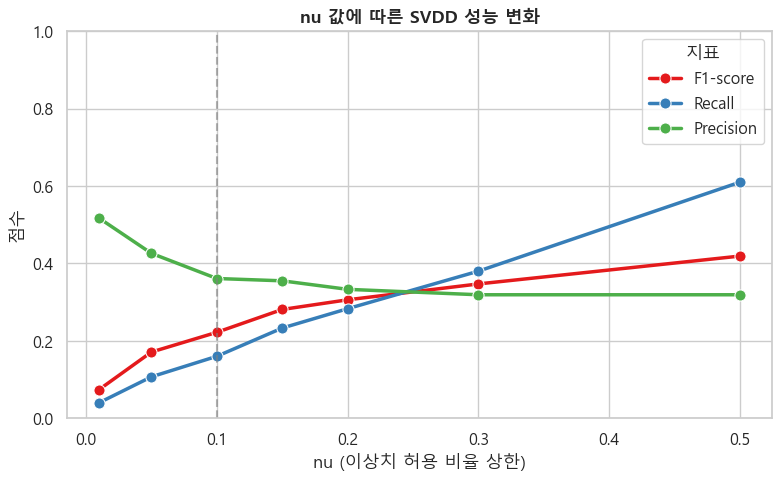

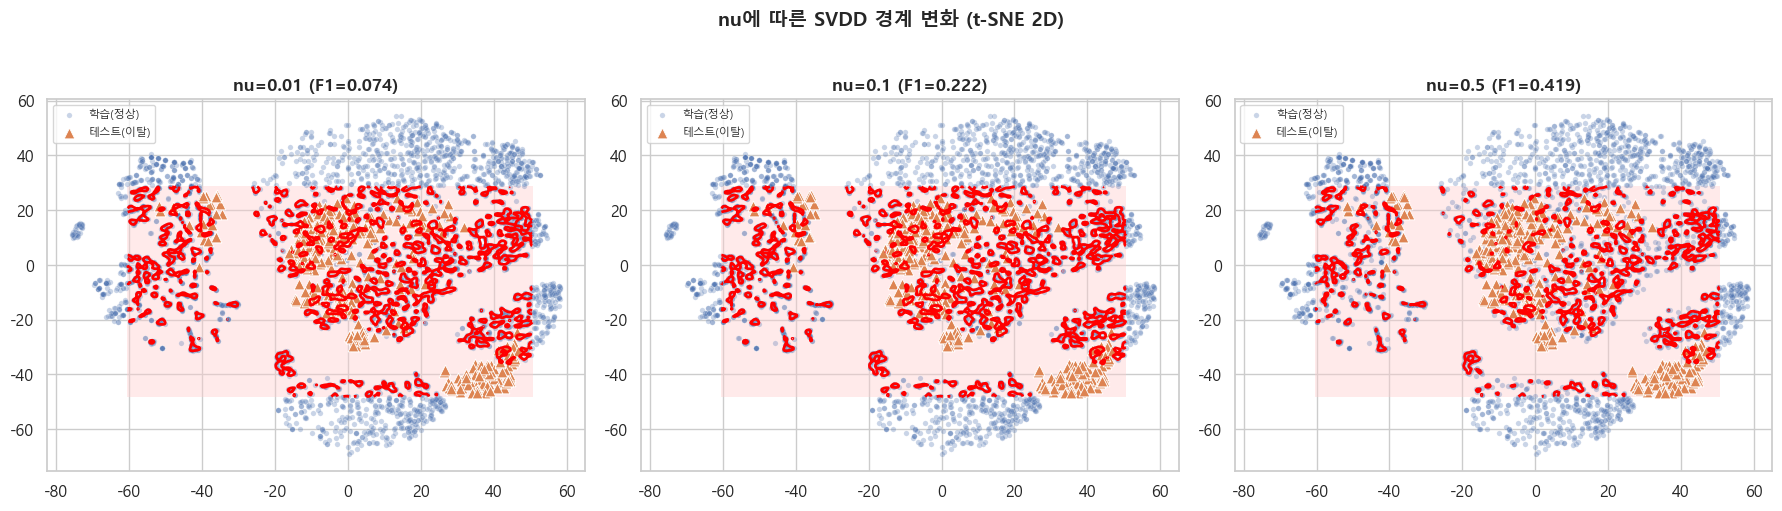


[해석]
  nu ↓ (0.01): 경계 넓음 → 정상을 잘 보존하지만 이탈 미탐지↑ (과소적합)
  nu ↑ (0.5): 경계 좁음 → 이탈 탐지↑ but 정상 오탐↑ (과적합)
  nu=0.1 전후가 F1 기준 균형점


In [15]:
# nu 값에 따른 SVDD 경계 및 성능 변화
nu_values = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
nu_results = []

for nu in nu_values:
    model = OneClassSVM(kernel="rbf", gamma="auto", nu=nu)
    model.fit(X_train_normal)
    pred = np.where(model.predict(X_test_scaled) == -1, 1, 0)
    nu_results.append({
        "nu": nu,
        "Accuracy": round(accuracy_score(y_test, pred), 3),
        "Precision": round(precision_score(y_test, pred, zero_division=0), 3),
        "Recall": round(recall_score(y_test, pred, zero_division=0), 3),
        "F1-score": round(f1_score(y_test, pred, zero_division=0), 3),
    })

nu_df = pd.DataFrame(nu_results)
print("=" * 60)
print("nu 파라미터별 SVDD 성능")
print("=" * 60)
display(nu_df)

# 성능 변화 라인 차트
setup_korean_font()
fig, ax = plt.subplots(figsize=(8, 5))
nu_melt = nu_df.melt(id_vars="nu", value_vars=["F1-score", "Recall", "Precision"],
                     var_name="지표", value_name="값")
sns.lineplot(data=nu_melt, x="nu", y="값", hue="지표", marker="o",
             linewidth=2.5, markersize=8, palette="Set1", ax=ax)
ax.set_title("nu 값에 따른 SVDD 성능 변화", fontweight="bold")
ax.set_xlabel("nu (이상치 허용 비율 상한)")
ax.set_ylabel("점수")
ax.set_ylim(0, 1)
ax.axvline(x=0.1, color="gray", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# t-SNE 2D에서 nu별 boundary 시각화 (3개 대표값)
tsne_2d = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=800)
X_train_2d = tsne_2d.fit_transform(X_train_scaled)
X_normal_2d = X_train_2d[y_train.values == 0]
X_test_2d = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=800).fit_transform(X_test_scaled)

xx, yy = np.meshgrid(
    np.linspace(X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1, 200),
    np.linspace(X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1, 200),
)
grid = np.c_[xx.ravel(), yy.ravel()]

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
for ax, nu in zip(axes2, [0.01, 0.1, 0.5]):
    m = OneClassSVM(kernel="rbf", gamma="auto", nu=nu)
    m.fit(X_normal_2d)
    Z = m.decision_function(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[Z.min(), 0], colors=["#ffcccc"], alpha=0.4)
    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors="red")
    sns.scatterplot(x=X_normal_2d[:, 0], y=X_normal_2d[:, 1],
                    color="#4C72B0", alpha=0.3, s=15, ax=ax, label="학습(정상)")
    churn_mask = y_test.values == 1
    sns.scatterplot(x=X_test_2d[churn_mask, 0], y=X_test_2d[churn_mask, 1],
                    color="#DD8452", marker="^", s=60, ax=ax, label="테스트(이탈)")
    f1 = nu_df.loc[nu_df["nu"] == nu, "F1-score"].values[0]
    ax.set_title(f"nu={nu} (F1={f1:.3f})", fontweight="bold")
    ax.legend(fontsize=8)

fig2.suptitle("nu에 따른 SVDD 경계 변화 (t-SNE 2D)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\n[해석]")
print("  nu ↓ (0.01): 경계 넓음 → 정상을 잘 보존하지만 이탈 미탐지↑ (과소적합)")
print("  nu ↑ (0.5): 경계 좁음 → 이탈 탐지↑ but 정상 오탐↑ (과적합)")
print("  nu=0.1 전후가 F1 기준 균형점")

## 7) 모델 결과 분석 및 비교

**[과제]** 써니는 지금까지 클래스 불균형 해결을 위해 시도한 Resampling과 One-Class Learning 중, 이 이탈 탐지 문제에는 어떤 접근이 더 적합한지 판단하고자 합니다. AI와 함께 두 접근의 성능을 한 표에 정리하고 어떤 상황에서 어떤 방법이 유리한지 인사이트를 도출해 보세요.

d:\autornd\SK Autonomous R&D\AutoRnDEnv\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
d:\autornd\SK Autonomous R&D\AutoRnDEnv\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(


[Optuna] XGBoost + Resampling 최적화 시작 (n_trials=100)


Best trial: 50. Best value: 0.640224: 100%|██████████| 100/100 [02:53<00:00,  1.74s/it]
d:\autornd\SK Autonomous R&D\AutoRnDEnv\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
d:\autornd\SK Autonomous R&D\AutoRnDEnv\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(


  Best CV F1: 0.6402
  Best params: {'resampling': 'smote', 'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.014517743422172264, 'subsample': 0.870827114861129, 'colsample_bytree': 0.8225735689389452, 'min_child_weight': 1, 'reg_alpha': 0.3245362602606274, 'reg_lambda': 7.843683510915119}

[Optuna] SVDD (nu, gamma) 최적화 시작 (n_trials=100)


Best trial: 71. Best value: 0.427004: 100%|██████████| 100/100 [03:55<00:00,  2.36s/it]


  Best CV F1: 0.4270
  Best params: {'nu': 0.33358404651257273, 'gamma_type': 'custom', 'gamma': 3.4159895110147565}

Optuna 최적화 후 테스트 성능 비교


,접근법,CV F1 (Optuna),Accuracy,Precision,Recall,F1-score,ROC-AUC,nu,gamma
0,XGBoost + SMOTE (Optuna),0.640,0.764,0.543,0.703,0.613,0.841,NaN,NaN
1,"SVDD (Optuna, nu=0.334)",0.427,0.335,0.275,0.920,0.423,0.479,0.334,3.416



★ 최적 조합 (Test F1 기준): XGBoost + SMOTE (Optuna)


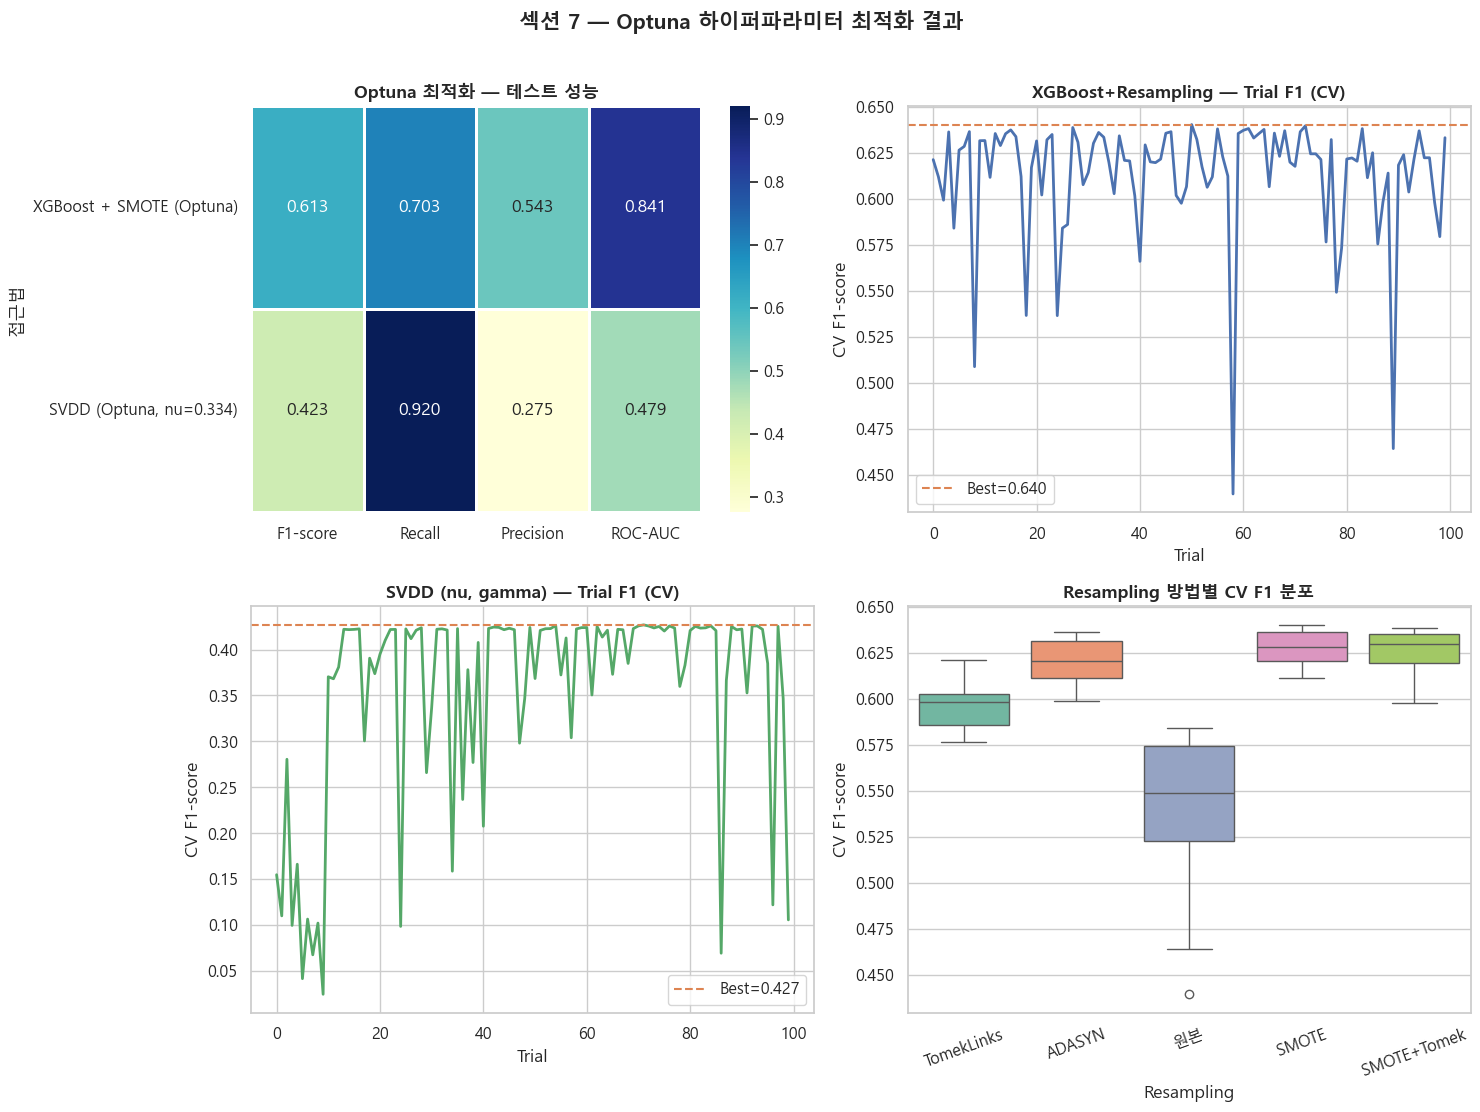

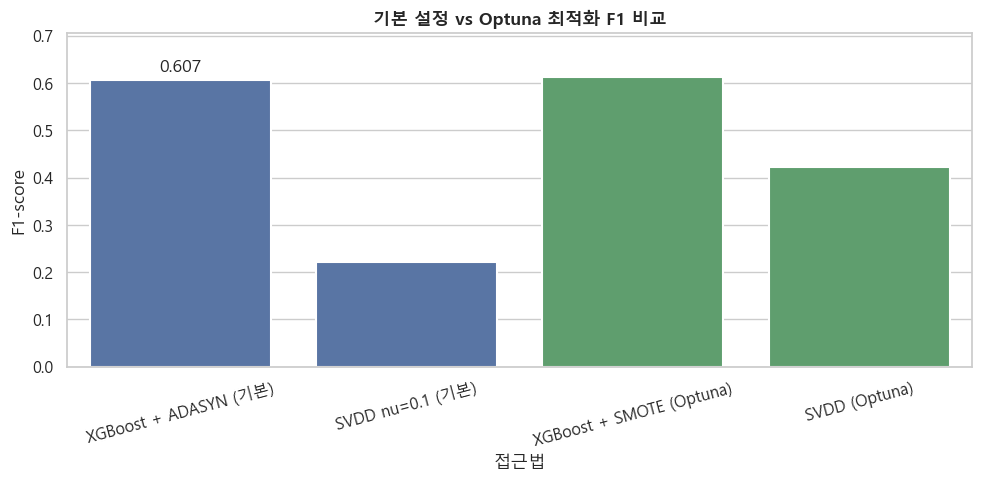


인사이트 요약

1. XGBoost + Resampling (Optuna)
   - 최적 Resampling: SMOTE
   - CV F1=0.640 → Test F1=0.613
   - TPESampler(multivariate)로 resampling·XGB 파라미터 동시 탐색

2. SVDD / One-Class SVM (Optuna)
   - 최적 nu=0.3336, gamma=3.4159895110147565
   - CV F1=0.427 → Test F1=0.423
   - nu↑ → 경계 좁아짐(과적합), gamma↑ → 결정경계 복잡도 증가

3. 최종 권장
   - Test F1 기준 최적: XGBoost + SMOTE (Optuna)
   - Churn 라벨이 충분할 때 → Optuna 튜닝된 XGBoost+Resampling 우선
   - SVDD는 nu·gamma Optuna 탐색으로 Recall- Precision 균형점 확보 가능
   - 실무: Optuna로 찾은 XGBoost 1차 + SVDD 2차 스크리닝 앙상블 검토



In [20]:
# ===== Optuna 하이퍼파라미터 최적화: XGBoost+Resampling vs SVDD =====
# Optuna 4.9 — TPESampler(multivariate/group), MedianPruner, trial.report 기반 CV Pruning

RESAMPLING_OPTIONS = {
    "none": lambda X, y: (X, y),
    "tomek": lambda X, y: TomekLinks().fit_resample(X, y),
    "smote": lambda X, y: SMOTE(random_state=42).fit_resample(X, y),
    "smote_tomek": lambda X, y: SMOTETomek(random_state=42).fit_resample(X, y),
    "adasyn": lambda X, y: ADASYN(random_state=42).fit_resample(X, y),
}
RESAMPLING_LABELS = {
    "none": "원본", "tomek": "TomekLinks", "smote": "SMOTE",
    "smote_tomek": "SMOTE+Tomek", "adasyn": "ADASYN",
}
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
N_TRIALS_XGB = 100
N_TRIALS_SVDD = 100


def apply_resampling(name, X, y):
    X_res, y_res = RESAMPLING_OPTIONS[name](X, y)
    return np.asarray(X_res), np.asarray(y_res)


def xgb_objective(trial):
    """Resampling 방법 + XGBoost 하이퍼파라미터 동시 탐색 (CV F1)"""
    resampling = trial.suggest_categorical("resampling", list(RESAMPLING_OPTIONS.keys()))
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }

    fold_scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(CV.split(X_train_scaled, y_train)):
        X_tr, X_va = X_train_scaled[tr_idx], X_train_scaled[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        X_res, y_res = apply_resampling(resampling, X_tr, y_tr)
        model = XGBClassifier(
            **params, random_state=42, eval_metric="logloss", verbosity=0,
        )
        model.fit(X_res, y_res)
        score = f1_score(y_va, model.predict(X_va), zero_division=0)
        fold_scores.append(score)

        trial.report(float(np.mean(fold_scores)), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))


def svdd_objective(trial):
    """One-Class SVM: nu + gamma 최적화 (CV F1, 정상 데이터만 학습)"""
    nu = trial.suggest_float("nu", 0.01, 0.5, log=True)
    gamma_type = trial.suggest_categorical("gamma_type", ["scale", "auto", "custom"])
    gamma = (
        trial.suggest_float("gamma", 1e-4, 10.0, log=True)
        if gamma_type == "custom" else gamma_type
    )

    fold_scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(CV.split(X_train_scaled, y_train)):
        X_tr, X_va = X_train_scaled[tr_idx], X_train_scaled[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        X_tr_normal = X_tr[y_tr.values == 0]

        if len(X_tr_normal) < 10:
            return 0.0

        model = OneClassSVM(kernel="rbf", gamma=gamma, nu=nu)
        model.fit(X_tr_normal)
        pred = np.where(model.predict(X_va) == -1, 1, 0)
        score = f1_score(y_va, pred, zero_division=0)
        fold_scores.append(score)

        trial.report(float(np.mean(fold_scores)), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))


# --- Study 1: XGBoost + Resampling ---
sampler_xgb = TPESampler(multivariate=True, group=True, seed=42)
study_xgb = optuna.create_study(
    direction="maximize",
    study_name="xgb_resampling",
    sampler=sampler_xgb,
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1),
)
print("=" * 70)
print(f"[Optuna] XGBoost + Resampling 최적화 시작 (n_trials={N_TRIALS_XGB})")
print("=" * 70)
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS_XGB, show_progress_bar=True)
print(f"  Best CV F1: {study_xgb.best_value:.4f}")
print(f"  Best params: {study_xgb.best_params}")

# --- Study 2: SVDD (One-Class SVM) ---
sampler_svdd = TPESampler(multivariate=True, group=True, seed=42)
study_svdd = optuna.create_study(
    direction="maximize",
    study_name="svdd",
    sampler=sampler_svdd,
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1),
)
print(f"\n[Optuna] SVDD (nu, gamma) 최적화 시작 (n_trials={N_TRIALS_SVDD})")
study_svdd.optimize(svdd_objective, n_trials=N_TRIALS_SVDD, show_progress_bar=True)
print(f"  Best CV F1: {study_svdd.best_value:.4f}")
print(f"  Best params: {study_svdd.best_params}")

# --- 최적 파라미터로 전체 학습 데이터 재학습 → 테스트 평가 ---
bp_xgb = study_xgb.best_params
X_best, y_best = apply_resampling(bp_xgb["resampling"], X_train_scaled, y_train)
best_xgb = XGBClassifier(
    n_estimators=bp_xgb["n_estimators"],
    max_depth=bp_xgb["max_depth"],
    learning_rate=bp_xgb["learning_rate"],
    subsample=bp_xgb["subsample"],
    colsample_bytree=bp_xgb["colsample_bytree"],
    min_child_weight=bp_xgb["min_child_weight"],
    reg_alpha=bp_xgb["reg_alpha"],
    reg_lambda=bp_xgb["reg_lambda"],
    random_state=42, eval_metric="logloss", verbosity=0,
)
best_xgb.fit(X_best, y_best)
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_score_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]
xgb_opt_metrics = evaluate_classifier(y_test, y_pred_xgb, y_score_xgb)

bp_svdd = study_svdd.best_params
gamma_best = (
    bp_svdd["gamma"] if bp_svdd["gamma_type"] == "custom" else bp_svdd["gamma_type"]
)
best_svdd = OneClassSVM(kernel="rbf", nu=bp_svdd["nu"], gamma=gamma_best)
best_svdd.fit(X_train_scaled[y_train.values == 0])
y_pred_svdd = np.where(best_svdd.predict(X_test_scaled) == -1, 1, 0)
y_score_svdd = -best_svdd.decision_function(X_test_scaled)
svdd_opt_metrics = evaluate_classifier(y_test, y_pred_svdd, y_score_svdd)

# --- 결과 표 ---
resampling_name = RESAMPLING_LABELS[bp_xgb["resampling"]]
opt_comparison = pd.DataFrame([
    {
        "접근법": f"XGBoost + {resampling_name} (Optuna)",
        "CV F1 (Optuna)": round(study_xgb.best_value, 3),
        **xgb_opt_metrics,
        "nu": np.nan, "gamma": np.nan,
    },
    {
        "접근법": f"SVDD (Optuna, nu={bp_svdd['nu']:.3f})",
        "CV F1 (Optuna)": round(study_svdd.best_value, 3),
        **svdd_opt_metrics,
        "nu": round(bp_svdd["nu"], 4),
        "gamma": gamma_best if isinstance(gamma_best, str) else round(gamma_best, 4),
    },
])

print("\n" + "=" * 70)
print("Optuna 최적화 후 테스트 성능 비교")
print("=" * 70)
display(opt_comparison.round(3))

best_approach = opt_comparison.loc[opt_comparison["F1-score"].idxmax(), "접근법"]
print(f"\n★ 최적 조합 (Test F1 기준): {best_approach}")

# --- 시각화 (seaborn) ---
setup_korean_font()
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# (1) 테스트 성능 히트맵
heat_cols = ["F1-score", "Recall", "Precision", "ROC-AUC"]
heat_data = opt_comparison.set_index("접근법")[heat_cols].astype(float)
sns.heatmap(heat_data, annot=True, fmt=".3f", cmap="YlGnBu",
            linewidths=1, linecolor="white", ax=axes[0, 0])
axes[0, 0].set_title("Optuna 최적화 — 테스트 성능", fontweight="bold")

# (2) Optuna Trial 이력 (XGBoost)
xgb_hist = study_xgb.trials_dataframe()
sns.lineplot(data=xgb_hist, x="number", y="value", ax=axes[0, 1], color="#4C72B0", linewidth=2)
axes[0, 1].axhline(study_xgb.best_value, color="#DD8452", linestyle="--", label=f"Best={study_xgb.best_value:.3f}")
axes[0, 1].set_title("XGBoost+Resampling — Trial F1 (CV)", fontweight="bold")
axes[0, 1].set_xlabel("Trial")
axes[0, 1].set_ylabel("CV F1-score")
axes[0, 1].legend()

# (3) Optuna Trial 이력 (SVDD)
svdd_hist = study_svdd.trials_dataframe()
sns.lineplot(data=svdd_hist, x="number", y="value", ax=axes[1, 0], color="#55A868", linewidth=2)
axes[1, 0].axhline(study_svdd.best_value, color="#DD8452", linestyle="--", label=f"Best={study_svdd.best_value:.3f}")
axes[1, 0].set_title("SVDD (nu, gamma) — Trial F1 (CV)", fontweight="bold")
axes[1, 0].set_xlabel("Trial")
axes[1, 0].set_ylabel("CV F1-score")
axes[1, 0].legend()

# (4) Resampling 방법별 Optuna Trial 분포
if "params_resampling" in xgb_hist.columns:
    xgb_hist["Resampling"] = xgb_hist["params_resampling"].map(RESAMPLING_LABELS)
    sns.boxplot(data=xgb_hist.dropna(subset=["value"]), x="Resampling", y="value",
                hue="Resampling", palette="Set2", dodge=False, legend=False, ax=axes[1, 1])
    axes[1, 1].set_title("Resampling 방법별 CV F1 분포", fontweight="bold")
    axes[1, 1].tick_params(axis="x", rotation=20)
    axes[1, 1].set_ylabel("CV F1-score")

fig.suptitle("섹션 7 — Optuna 하이퍼파라미터 최적화 결과", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# --- 기본(수동) vs Optuna 비교 ---
try:
    baseline = pd.DataFrame([
        {"접근법": f"XGBoost + {resampling_df['F1-score'].idxmax()} (기본)", "F1-score": resampling_df["F1-score"].max()},
        {"접근법": "SVDD nu=0.1 (기본)", "F1-score": svdd_metrics["F1-score"]},
        {"접근법": f"XGBoost + {resampling_name} (Optuna)", "F1-score": xgb_opt_metrics["F1-score"]},
        {"접근법": "SVDD (Optuna)", "F1-score": svdd_opt_metrics["F1-score"]},
    ])
    setup_korean_font()
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    sns.barplot(data=baseline, x="접근법", y="F1-score", hue="접근법",
                palette=["#4C72B0", "#4C72B0", "#55A868", "#55A868"],
                edgecolor="white", linewidth=1.5, dodge=False, legend=False, ax=ax2)
    ax2.bar_label(ax2.containers[0], fmt="%.3f", padding=3)
    ax2.set_title("기본 설정 vs Optuna 최적화 F1 비교", fontweight="bold")
    ax2.tick_params(axis="x", rotation=15)
    ax2.set_ylim(0, max(baseline["F1-score"]) * 1.15)
    plt.tight_layout()
    plt.show()
except NameError:
    pass

print("\n" + "=" * 70)
print("인사이트 요약")
print("=" * 70)
print(f"""
1. XGBoost + Resampling (Optuna)
   - 최적 Resampling: {resampling_name}
   - CV F1={study_xgb.best_value:.3f} → Test F1={xgb_opt_metrics['F1-score']:.3f}
   - TPESampler(multivariate)로 resampling·XGB 파라미터 동시 탐색

2. SVDD / One-Class SVM (Optuna)
   - 최적 nu={bp_svdd['nu']:.4f}, gamma={gamma_best}
   - CV F1={study_svdd.best_value:.3f} → Test F1={svdd_opt_metrics['F1-score']:.3f}
   - nu↑ → 경계 좁아짐(과적합), gamma↑ → 결정경계 복잡도 증가

3. 최종 권장
   - Test F1 기준 최적: {best_approach}
   - Churn 라벨이 충분할 때 → Optuna 튜닝된 XGBoost+Resampling 우선
   - SVDD는 nu·gamma Optuna 탐색으로 Recall- Precision 균형점 확보 가능
   - 실무: Optuna로 찾은 XGBoost 1차 + SVDD 2차 스크리닝 앙상블 검토
""")

C:\Users\Admin\AppData\Local\Temp\ipykernel_6252\1948323643.py:85: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler_gps = GPSampler(seed=42)


[Optuna] GPSampler Pareto 최적화 시작 (n_trials=300)
목표: CV F1, Recall, Precision 동시 최대화


100%|██████████| 300/300 [16:33<00:00,  3.31s/it]



GPSampler Pareto Frontier Trial 수: 75


,Trial,Resampling,CV F1,CV Recall,CV Precision,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_alpha,reg_lambda
0,147,SMOTE,0.6392,0.7030,0.5864,300,3,0.0404,0.6000,0.6000,10,10.0000,0.0010
1,275,SMOTE,0.6391,0.7398,0.5628,150,6,0.0128,1.0000,0.6000,10,0.9328,0.0365
2,23,SMOTE+Tomek,0.6390,0.6849,0.5992,250,5,0.0379,0.6000,0.6000,4,7.9481,0.0278
3,25,SMOTE+Tomek,0.6381,0.6883,0.5951,250,5,0.0343,0.6000,0.6000,6,7.8430,0.0361
4,258,SMOTE,0.6377,0.7398,0.5607,200,8,0.0100,1.0000,0.6000,10,10.0000,0.0010
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,202,원본,0.4388,0.3151,0.7323,100,6,0.0110,0.6245,1.0000,10,0.0010,0.0010
71,203,원본,0.4387,0.3137,0.7378,100,6,0.0109,0.6161,1.0000,10,0.0010,0.0010
72,31,원본,0.3935,0.2676,0.7533,100,3,0.0116,0.8023,0.8208,10,0.0010,0.0010
73,163,원본,0.3036,0.1880,0.7906,100,6,0.0106,0.6000,1.0000,8,10.0000,10.0000


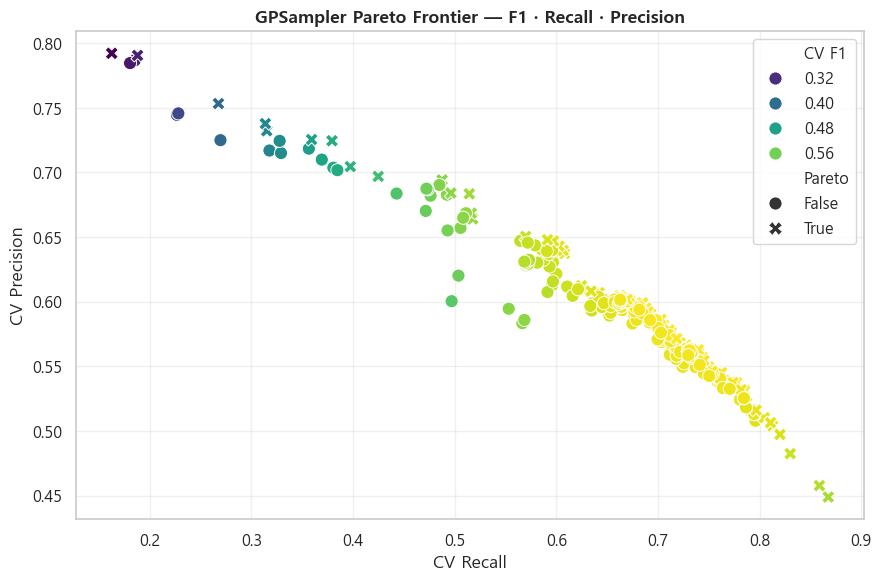


상위 Pareto 후보 (CV F1 기준)


,Trial,Resampling,CV F1,CV Recall,CV Precision
0,147,SMOTE,0.6392,0.7030,0.5864
1,275,SMOTE,0.6391,0.7398,0.5628
2,23,SMOTE+Tomek,0.6390,0.6849,0.5992
3,25,SMOTE+Tomek,0.6381,0.6883,0.5951
4,258,SMOTE,0.6377,0.7398,0.5607
5,26,SMOTE+Tomek,0.6377,0.7057,0.5818
6,210,SMOTE+Tomek,0.6375,0.7110,0.5782
7,24,SMOTE+Tomek,0.6375,0.6930,0.5905
8,64,SMOTE+Tomek,0.6374,0.6903,0.5923
9,136,SMOTE,0.6372,0.7130,0.5763


In [23]:
# ===== GPSampler 다목적 최적화: F1 · Recall · Precision Pareto Frontier =====
# 기존 TPESampler 단일 F1 최적화와 별도로, 새 Study에서 3개 지표를 동시에 최대화합니다.

try:
    from optuna.samplers import GPSampler
except ImportError as exc:
    raise ImportError("GPSampler를 사용하려면 Optuna 4.x 이상이 필요합니다. `pip install -U optuna` 후 다시 실행하세요.") from exc

if "RESAMPLING_OPTIONS" not in globals():
    RESAMPLING_OPTIONS = {
        "none": lambda X, y: (X, y),
        "tomek": lambda X, y: TomekLinks().fit_resample(X, y),
        "smote": lambda X, y: SMOTE(random_state=42).fit_resample(X, y),
        "smote_tomek": lambda X, y: SMOTETomek(random_state=42).fit_resample(X, y),
        "adasyn": lambda X, y: ADASYN(random_state=42).fit_resample(X, y),
    }

if "RESAMPLING_LABELS" not in globals():
    RESAMPLING_LABELS = {
        "none": "원본", "tomek": "TomekLinks", "smote": "SMOTE",
        "smote_tomek": "SMOTE+Tomek", "adasyn": "ADASYN",
    }

if "CV" not in globals():
    CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

if "apply_resampling" not in globals():
    def apply_resampling(name, X, y):
        X_res, y_res = RESAMPLING_OPTIONS[name](X, y)
        return np.asarray(X_res), np.asarray(y_res)

RESAMPLING_KEYS_GPS = list(RESAMPLING_OPTIONS.keys())
N_TRIALS_GPS_PARETO = 300


def _take_y(y, idx):
    return y.iloc[idx] if hasattr(y, "iloc") else y[idx]


def xgb_gps_pareto_objective(trial):
    """GPSampler로 XGBoost+Resampling의 CV F1, Recall, Precision을 동시 최대화합니다."""
    resampling_idx = trial.suggest_int("resampling_idx", 0, len(RESAMPLING_KEYS_GPS) - 1)
    resampling = RESAMPLING_KEYS_GPS[resampling_idx]
    trial.set_user_attr("resampling", resampling)
    trial.set_user_attr("resampling_label", RESAMPLING_LABELS[resampling])

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }

    fold_f1, fold_recall, fold_precision = [], [], []
    for tr_idx, va_idx in CV.split(X_train_scaled, y_train):
        X_tr, X_va = X_train_scaled[tr_idx], X_train_scaled[va_idx]
        y_tr, y_va = _take_y(y_train, tr_idx), _take_y(y_train, va_idx)

        try:
            X_res, y_res = apply_resampling(resampling, X_tr, y_tr)
            model = XGBClassifier(
                **params, random_state=42, eval_metric="logloss", verbosity=0,
            )
            model.fit(X_res, y_res)
            y_pred = model.predict(X_va)
        except ValueError:
            # 일부 resampling 조합은 fold 내 클래스 분포에 따라 실패할 수 있으므로 지배되지 않게 최저점 처리합니다.
            return 0.0, 0.0, 0.0

        fold_f1.append(f1_score(y_va, y_pred, zero_division=0))
        fold_recall.append(recall_score(y_va, y_pred, zero_division=0))
        fold_precision.append(precision_score(y_va, y_pred, zero_division=0))

    return (
        float(np.mean(fold_f1)),
        float(np.mean(fold_recall)),
        float(np.mean(fold_precision)),
    )


sampler_gps = GPSampler(seed=42)
study_xgb_gps_pareto = optuna.create_study(
    directions=["maximize", "maximize", "maximize"],
    study_name="xgb_resampling_gps_pareto",
    sampler=sampler_gps,
)

print("=" * 80)
print(f"[Optuna] GPSampler Pareto 최적화 시작 (n_trials={N_TRIALS_GPS_PARETO})")
print("목표: CV F1, Recall, Precision 동시 최대화")
print("=" * 80)
study_xgb_gps_pareto.optimize(
    xgb_gps_pareto_objective,
    n_trials=N_TRIALS_GPS_PARETO,
    show_progress_bar=True,
    n_jobs=-1
)

pareto_trials_gps = sorted(
    study_xgb_gps_pareto.best_trials,
    key=lambda t: (t.values[0], t.values[1], t.values[2]),
    reverse=True,
)

pareto_frontier_gps_df = pd.DataFrame([
    {
        "Trial": t.number,
        "Resampling": t.user_attrs["resampling_label"],
        "CV F1": t.values[0],
        "CV Recall": t.values[1],
        "CV Precision": t.values[2],
        "n_estimators": t.params["n_estimators"],
        "max_depth": t.params["max_depth"],
        "learning_rate": t.params["learning_rate"],
        "subsample": t.params["subsample"],
        "colsample_bytree": t.params["colsample_bytree"],
        "min_child_weight": t.params["min_child_weight"],
        "reg_alpha": t.params["reg_alpha"],
        "reg_lambda": t.params["reg_lambda"],
    }
    for t in pareto_trials_gps
])

print("\n" + "=" * 80)
print(f"GPSampler Pareto Frontier Trial 수: {len(pareto_frontier_gps_df)}")
print("=" * 80)
display(pareto_frontier_gps_df.round(4))

# Pareto frontier를 Precision-Recall 평면에서 확인합니다. 색상은 F1 값입니다.
all_trials_gps_df = pd.DataFrame([
    {
        "Trial": t.number,
        "CV F1": t.values[0],
        "CV Recall": t.values[1],
        "CV Precision": t.values[2],
        "Pareto": t.number in {pt.number for pt in pareto_trials_gps},
    }
    for t in study_xgb_gps_pareto.trials
    if t.values is not None
])

setup_korean_font()
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=all_trials_gps_df,
    x="CV Recall", y="CV Precision", hue="CV F1", style="Pareto",
    palette="viridis", s=90, edgecolor="white", linewidth=0.7, ax=ax,
)
ax.set_title("GPSampler Pareto Frontier — F1 · Recall · Precision", fontweight="bold")
ax.set_xlabel("CV Recall")
ax.set_ylabel("CV Precision")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n상위 Pareto 후보 (CV F1 기준)")
display(pareto_frontier_gps_df[["Trial", "Resampling", "CV F1", "CV Recall", "CV Precision"]].head(10).round(4))